一，实践：Section 4.7 Lab: Classification Methods

我们将首先研究作为ISLR2库一部分的Smarket数据的一些数字和图形摘要。这个数据集包括标准普尔500指数从2001年初到2005年底1,250天的百分比回报率。对于每个日期，我们记录了前5个交易日（从Lag1到Lag5）的回报率百分比。我们还记录了Volume（前一天交易的股票数量，以十亿计），Today（上述日期的回报率百分比）和Direction（该日期的市场是涨还是跌）。我们的目标是使用其他特征来预测Direction（一种定性相应变量）。

In [2]:
# The Stock Market Data
library(ISLR2)
names(Smarket)   
dim(Smarket) # 1250 x 9  
summary(Smarket) 

[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

[1] 1250    9

      Year           Lag1                Lag2                Lag3          
 Min.   :2001   Min.   :-4.922000   Min.   :-4.922000   Min.   :-4.922000  
 1st Qu.:2002   1st Qu.:-0.639500   1st Qu.:-0.639500   1st Qu.:-0.640000  
 Median :2003   Median : 0.039000   Median : 0.039000   Median : 0.038500  
 Mean   :2003   Mean   : 0.003834   Mean   : 0.003919   Mean   : 0.001716  
 3rd Qu.:2004   3rd Qu.: 0.596750   3rd Qu.: 0.596750   3rd Qu.: 0.596750  
 Max.   :2005   Max.   : 5.733000   Max.   : 5.733000   Max.   : 5.733000  
      Lag4                Lag5              Volume           Today          
 Min.   :-4.922000   Min.   :-4.92200   Min.   :0.3561   Min.   :-4.922000  
 1st Qu.:-0.640000   1st Qu.:-0.64000   1st Qu.:1.2574   1st Qu.:-0.639500  
 Median : 0.038500   Median : 0.03850   Median :1.4229   Median : 0.038500  
 Mean   : 0.001636   Mean   : 0.00561   Mean   :1.4783   Mean   : 0.003138  
 3rd Qu.: 0.596750   3rd Qu.: 0.59700   3rd Qu.:1.6417   3rd Qu.: 0.596750  
 Max. 

In [3]:
head(Smarket) 

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,2001,0.381,-0.192,-2.624,-1.055,5.010,1.1913,0.959,Up
2,2001,0.959,0.381,-0.192,-2.624,-1.055,1.2965,1.032,Up
3,2001,1.032,0.959,0.381,-0.192,-2.624,1.4112,-0.623,Down
4,2001,-0.623,1.032,0.959,0.381,-0.192,1.2760,0.614,Up
5,2001,0.614,-0.623,1.032,0.959,0.381,1.2057,0.213,Up
6,2001,0.213,0.614,-0.623,1.032,0.959,1.3491,1.392,Up


In [4]:
# 我们想要获取每一个预测变量之间的配对相关系数
# cor(Smarket) # x，因为var列中有一个非数值型变量

cor(Smarket[,-9]) # 除去最后一列factor因子列


,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00000000,0.029699649,0.030596422,0.033194581,0.035688718,0.029787995,0.53900647,0.030095229
Lag1,0.02969965,1.000000000,-0.026294328,-0.010803402,-0.002985911,-0.005674606,0.04090991,-0.026155045
Lag2,0.03059642,-0.026294328,1.000000000,-0.025896670,-0.010853533,-0.003557949,-0.04338321,-0.010250033
Lag3,0.03319458,-0.010803402,-0.025896670,1.000000000,-0.024051036,-0.018808338,-0.04182369,-0.002447647
Lag4,0.03568872,-0.002985911,-0.010853533,-0.024051036,1.000000000,-0.027083641,-0.04841425,-0.006899527
Lag5,0.02978799,-0.005674606,-0.003557949,-0.018808338,-0.027083641,1.000000000,-0.02200231,-0.034860083
Volume,0.53900647,0.040909908,-0.043383215,-0.041823686,-0.048414246,-0.022002315,1.00000000,0.014591823
Today,0.03009523,-0.026155045,-0.010250033,-0.002447647,-0.006899527,-0.034860083,0.01459182,1.000000000


观察上面的相关性矩阵，我们可以发现Lag变量与Today之间二代return基本上相关性接近于0。换句话说，今天的回报率和前几天的回报率之间似乎没有什么相关性。

唯一显著的相关性是年份和成交量Volume之间的关系。通过绘制按时间顺序排列的数据，我们可以看到Volume随着时间的推移而增加。换句话说，从2001年到2005年，平均每日交易的股票数量增加了。              

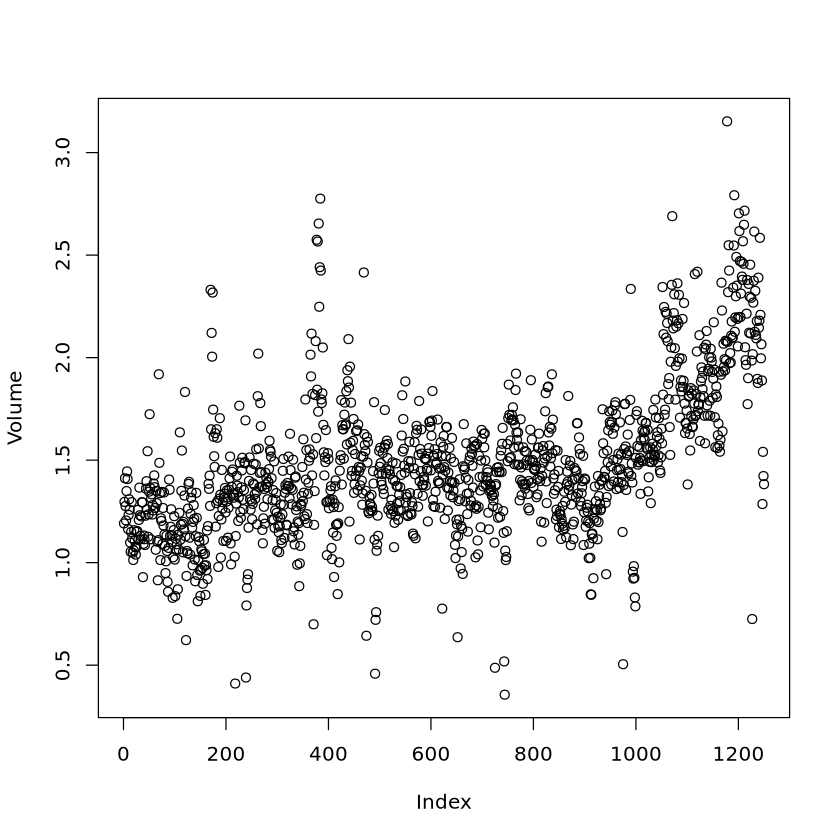

In [6]:
# 绘制成交量Volume与index变量之间的关系 
# 由于我没有指定x轴的数据，plot函数默认会使用Volume的索引值作为x轴的数据。因此，绘制出来的图形是Volume随索引值变化的折线图
# 此处的index其实就是行索引，就是第1行到第1250行，因为我们的时序数据恰好是按照时间顺序排列的，所以这个图形看起来就像是Volume随时间变化的折线图
attach(Smarket)
  
plot(Volume)    

In [7]:
# 查看Smarket数据框的索引值
head(1:nrow(Smarket))

# 查看Smarket数据框的索引值和对应的Volume值
data.frame(Index = 1:nrow(Smarket), Volume = Smarket$Volume)

[1] 1 2 3 4 5 6

Index,Volume
<int>,<dbl>
1,1.1913
2,1.2965
3,1.4112
4,1.2760
5,1.2057
6,1.3491
7,1.4450
8,1.4078
9,1.1640


1，Logistic Regression 逻辑斯蒂回归

接下来，我们将拟合逻辑回归模型，以利用Lag1到Lag5即前5个交易日的回报率百分比，和Volume数据即前一天交易的股票数量，来预测当天股票市场是涨还是跌。

glm（）函数可以用来拟合许多类型的广义线性模型，包括逻辑回归。

glm（）函数的语法与lm（）类似，不同的是我们必须传入参数family = binomial来告诉R运行逻辑回归，而不是其他类型的广义线性模型。

family: a description of the error distribution and link function to
          be used in the model.  For ‘glm’ this can be a character
          string naming a family function, a family function or the
          result of a call to a family function.  For ‘glm.fit’ only
          the third option is supported.  (See ‘family’ for details of
          family functions.)

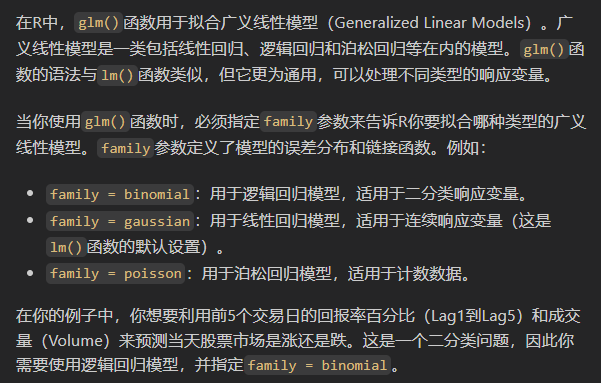

binomal(link='logit')：响应变量服从二项分布，连接函数为logit

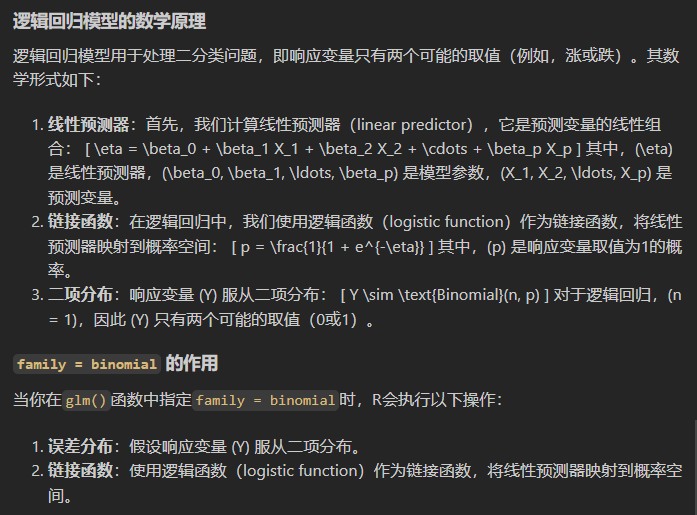

In [9]:
glm.fits <- glm(
Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume,
data = Smarket, family = binomial
)
summary(glm.fits)


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept) -0.126000   0.240736  -0.523    0.601
Lag1        -0.073074   0.050167  -1.457    0.145
Lag2        -0.042301   0.050086  -0.845    0.398
Lag3         0.011085   0.049939   0.222    0.824
Lag4         0.009359   0.049974   0.187    0.851
Lag5         0.010313   0.049511   0.208    0.835
Volume       0.135441   0.158360   0.855    0.392

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1731.2  on 1249  degrees of freedom
Residual deviance: 1727.6  on 1243  degrees of freedom
AIC: 1741.6

Number of Fisher Scoring iterations: 3


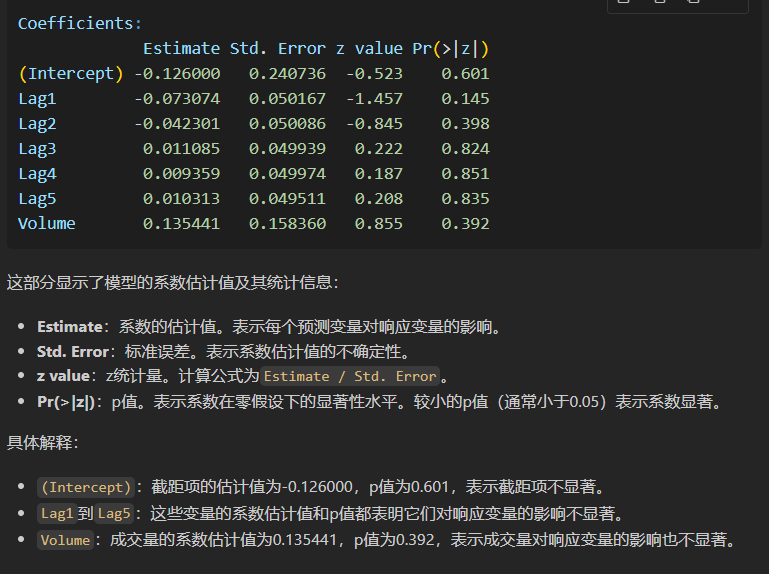

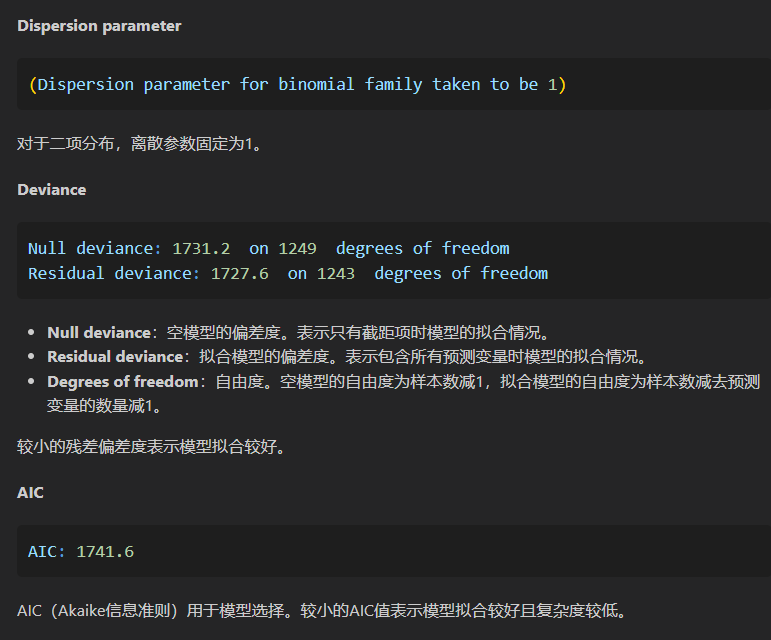

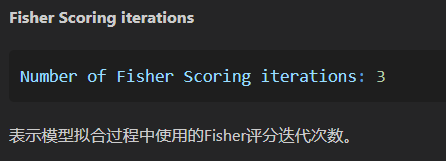

这里最小的p值与Lag1相关。这一预测的负系数表明，如果市场昨天有正回报，那么今天就不太可能上涨。然而，在值为0.15时，p值仍然比较大，因此没有明确的证据表明Lag1和Direction之间存在真正的关联

In [12]:
# 我们使用coef（）函数来获取这个拟合模型的系数。我们还可以使用summary（）函数来访问拟合模型的特定方面，例如系数的p值。
coef(glm.fits)
summary(glm.fits)$coef
summary(glm.fits)$coef[, 4] #其实就是第四列，也就是p值

(Intercept)         Lag1         Lag2         Lag3         Lag4         Lag5 
-0.126000257 -0.073073746 -0.042301344  0.011085108  0.009358938  0.010313068 
      Volume 
 0.135440659

,Estimate,Std. Error,z value,Pr(>|z|)
(Intercept),-0.126000257,0.24073574,-0.5233966,0.6006983
Lag1,-0.073073746,0.05016739,-1.4565986,0.1452272
Lag2,-0.042301344,0.05008605,-0.8445733,0.3983491
Lag3,0.011085108,0.04993854,0.2219750,0.8243333
Lag4,0.009358938,0.04997413,0.1872757,0.8514445
Lag5,0.010313068,0.04951146,0.2082966,0.8349974
Volume,0.135440659,0.15835970,0.8552723,0.3924004


(Intercept)        Lag1        Lag2        Lag3        Lag4        Lag5 
  0.6006983   0.1452272   0.3983491   0.8243333   0.8514445   0.8349974 
     Volume 
  0.3924004

predict（）函数可用于预测给定预测变量值的前提下的市场上涨概率。

type = "response"选项告诉R输出P（Y = 1|X）形式的概率，而不是其他信息（如logit）。

如果未向predict（）函数提供数据集，则计算用于建立逻辑回归模型的训练数据的概率。

这里我们只打印了前十个概率。我们知道这些值对应的是市场上涨的概率，而不是下跌的概率，因为contrast（）函数表明R已经创建了一个哑变量，其中1代表up。

In [13]:
contrasts(Direction)

,Up
Down,0
Up,1


predict(glm.fits, type = "response")返回的是模型对每个观测值的预测概率，即响应变量取值为1的概率。

type = "response"参数指定了返回的预测值为概率。

In [ ]:
glm.probs <- predict(glm.fits, type = "response")  # 这里没有指定新的数据集，所以默认使用训练数据集，所以返回的是训练数据集中对于每一个观测也就是每一天的涨跌为涨的概率


# 我们可以使用ifelse（）函数来将这些概率转换为涨跌预测
glm.pred <- ifelse(glm.probs > 0.5, "Up", "Down")  # 如果概率大于0.5，我们就预测为涨，否则预测为跌
# 我们可以使用table（）函数来查看我们的预测结果和真实结果之间的交叉表
table(glm.pred, Direction)
# Direction == Smarket$Direction

glm.probs[1:10] 

        Direction
glm.pred Down  Up
    Down  145 141
    Up    457 507

1         2         3         4         5         6         7         8 
0.5070841 0.4814679 0.4811388 0.5152224 0.5107812 0.5069565 0.4926509 0.5092292 
        9        10 
0.5176135 0.4888378

仔细比对一下：

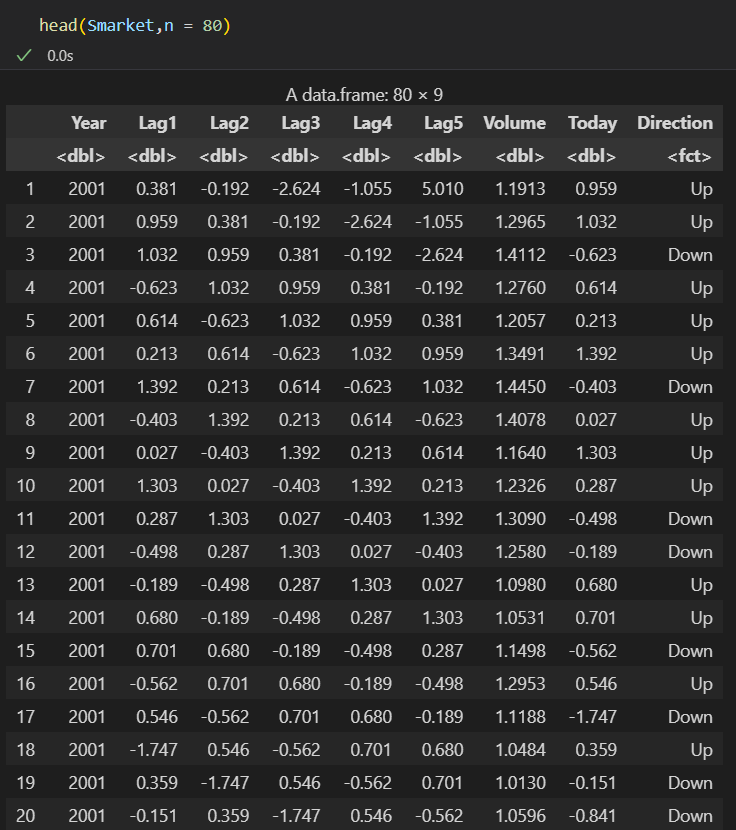

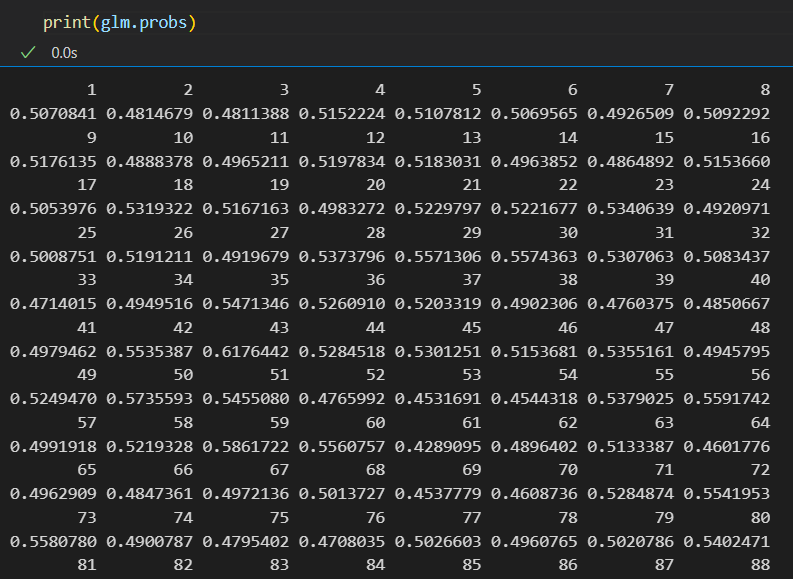

再依据我们的table交叉列联表，其实就可以发现确实是估计有问题

为了预测市场在某一天是上涨还是下跌，我们必须将这些预测的概率转换成类别标签，上涨还是下跌。下面两个命令根据市场增长的预测概率是大于还是小于0.5来创建一个类预测向量。

第一个命令创建一个包含1,250个Down元素的向量。第二行将所有预测市场上涨概率超过0.5的元素转换为Up。根据这些预测，table（）函数可以用来产生一个混淆矩阵，以确定有多少观测值被正确或错误地分类。

In [ ]:
# 我们前面是手动调整阈值为0.5，即glm.pred

# 教程中提供的pred同理glm.pred2
glm.pred <- rep("Down", 1250) # 一共是1250个观测
glm.pred[glm.probs > .5] = "Up"
glm.pred[1:10]

# 我们可以使用table（）函数来查看我们的预测结果和真实结果之间的交叉表，实际上就是混淆矩阵，行是预测结果，列是真实结果
table(glm.pred, Direction)

[1] "Up"   "Down" "Down" "Up"   "Up"   "Up"   "Down" "Up"   "Up"   "Down"

        Direction
glm.pred Down  Up
    Down  145 141
    Up    457 507

In [30]:
# 其实这个混淆矩阵很容易理解，对角线上的元素表示我们预测正确的数量，非对角线上的元素表示我们预测错误的数量（注意对角线指的是从左上到右下的对角线）
(507 + 145) / 1250 # 我们查看一下总共有多少个观测是我们预测正确的，即对角线上的元素之和

[1] 0.5216

In [ ]:
mean(glm.pred == Direction) # 计算我们的预测准确率，即预测正确的数量除以总的观测数量，和上面一样，其实逻辑就是频率加权

[1] 0.5216

混淆矩阵的对角线元素表示正确的预测，而对角线表示错误的预测。因此，我们的模型正确地预测了市场在507天会上涨，在145天会下跌，总共507 + 145 = 652个正确的预测。mean（）函数可用于计算预测正确的天数百分比。在这种情况下，逻辑回归正确预测了52.2%的市场运动

乍一看，逻辑回归模型似乎比随机猜测要好一些。然而，这个结果是有误导性的，因为我们在相同的1250个观测数据上训练和测试了这个模型。即100%−52.2% = 47.8%，为训练错误率。正如我们之前看到的，训练错误率通常过于乐观——往往会低估测试错误率。为了更好地评估逻辑回归模型在这种情况下的准确性，我们可以使用部分数据拟合模型，然后检查它如何预测持有的数据。这将产生一个更现实的错误率，也就是说，在实践中，我们感兴趣的不是我们用来拟合模型的数据，而是未来市场走势未知的日子。

为了实施这一策略，我们将首先创建一个与2001 ~ 2004年观察值相对应的矢量。然后，我们将使用这个矢量创建一个2005年以来的观测数据集

即使用01-04年的数据作为训练数据来拟合一个逻辑回归模型，然后再使用05年的数据来进行测试

In [7]:
train <- (Year < 2005)
# train 实际上返回的是一个逻辑索引向量，布尔向量可用来获得矩阵的行或列的子集
Smarket.2005 <- Smarket[!train, ] # 2005年的数据，即测试集的x+y
dim(Smarket.2005)
Direction.2005 <- Direction[!train] # 2005年的数据对应的涨跌方向，即测试集的y

[1] 252   9

In [ ]:
train_data <- (Smarket$Year < 2005)
train_data
# 此处效果同上面的train

[1]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [13]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [25]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [37]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [49]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [61]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [73]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [85]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
  [97]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [109]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [121]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [133]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [145]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [157]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [169]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [181]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [193]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [205]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [217]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [229]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [241]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [253]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [265]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [277]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [289]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [301]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [313]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [325]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [337]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [349]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [361]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [373]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [385]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [397]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [409]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [421]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [433]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [445]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [457]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [469]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [481]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [493]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [505]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [517]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [529]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [541]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [553]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [565]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [577]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [589]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE
 [601]  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRUE  TRU

我们现在只使用2005年之前的观测数据子集，使用子集subset参数来拟合逻辑回归模型。然后，我们获得了测试集中每一天（即2005年的每一天）股票市场上涨的预测概率。

In [ ]:
# subset参数用来指定在模型拟合过程中使用的数据集，这里我们指定了train_data，也就是只使用2005年之前的数据来拟合模型
glm.fits <- glm(
Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + Volume,
data = Smarket, family = binomial, subset = train
)
summary(glm.fits)  


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Smarket, subset = train)

Coefficients:
             Estimate Std. Error z value Pr(>|z|)
(Intercept)  0.191213   0.333690   0.573    0.567
Lag1        -0.054178   0.051785  -1.046    0.295
Lag2        -0.045805   0.051797  -0.884    0.377
Lag3         0.007200   0.051644   0.139    0.889
Lag4         0.006441   0.051706   0.125    0.901
Lag5        -0.004223   0.051138  -0.083    0.934
Volume      -0.116257   0.239618  -0.485    0.628

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1383.3  on 997  degrees of freedom
Residual deviance: 1381.1  on 991  degrees of freedom
AIC: 1395.1

Number of Fisher Scoring iterations: 3


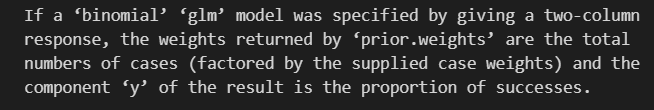

In [ ]:
glm.probs <- predict(glm.fits, Smarket.2005,type = "response")  # 这里指定了新的数据集，所以返回的是新的数据集中对于每一个观测也就是每一天的涨跌为涨的概率


glm.probs <- predict(glm.fits, Smarket.2005,type = "response") ——我很好奇的是为什么这里使用的是 Smarket.2005，按理来说测试集不是不应该提供y标签的吗，为什么使用的是全部的2005的数据？

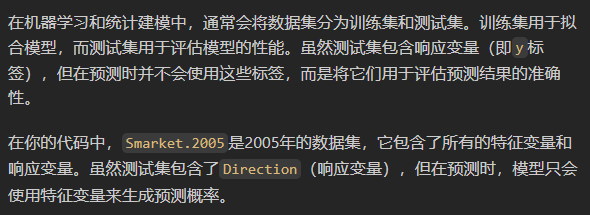

In [41]:
glm.pred <- ifelse(glm.probs > 0.5,"UP","Down")

# 或者按照教材中提供的方式：
# glm.pred <- rep("Down", 252)
# glm.pred[glm.probs > .5] <- "Up"

table(glm.pred, Direction.2005)  # 我们习惯在table中先列出预测结果，再列出真实结果，其实就是对应混淆矩阵中行列的习惯

mean(glm.pred == Direction.2005) # 预测准确率
mean(glm.pred != Direction.2005) # 预测错误率

        Direction.2005
glm.pred Down Up
    Down   77 97
    UP     34 44

[1] 0.3055556

[1] 0.6944444

结果相当令人失望：测试错误率是52%，这比随机猜测更糟糕！当然，这个结果并不那么令人惊讶，因为人们通常不会指望能够用前几天的回报来预测未来的市场表现。（毕竟，如果这样做是可能的，那么本书的作者将会大赚一笔，而不是写一本统计教科书。）

因为实际上测试集上的错误率也只是一个一个数出来的统计频率结果，对于2005年每一天的预测结果，我五五开胡乱猜测的话，实际上也能够猜个50%的概率，但是一年365天，取个数学期望就不一定了，但是总之在测试集上这个结果和胡乱猜没有什么区别

我们回想一下，逻辑回归模型中所有预测因子的p值都非常令人失望，而最小的p值，虽然不是很小，却对应于Lag1。也许通过去除对预测方向没有帮助的变量，我们可以获得一个更有效的模型。毕竟，使用与响应无关的预测因素往往会导致测试错误率的恶化（因为这样的预测因素会导致方差的增加，而没有相应的偏差的减少），因此去除这样的预测因素反过来可能会产生改进。下面我们仅使用Lag1和Lag2对逻辑回归进行了修正，这似乎在原始逻辑回归模型中具有最高的预测能力。

In [43]:
glm.fits <- glm(Direction ~ Lag1 + Lag2, data = Smarket,family = binomial, subset = train)
glm.probs <- predict(glm.fits, Smarket.2005,type = "response")
glm.pred <- ifelse(glm.probs > 0.5,"Up","Down")
table(glm.pred, Direction.2005)
mean(glm.pred == Direction.2005)

        Direction.2005
glm.pred Down  Up
    Down   35  35
    Up     76 106

[1] 0.5595238

现在，结果似乎好了一点：56%的每日运动都得到了正确的预测。值得注意的是，在这种情况下，预测市场每天都会增长的更简单的策略在56%的情况下是正确的！因此，就总体错误率而言，逻辑回归方法并不比朴素方法好。然而，混淆矩阵显示，在逻辑回归预测市场增长的日子里，它有58%的准确率。这提示了一种可能的交易策略，即在模型预测市场上涨的日子买入，而在预测市场下跌的日子避免交易。当然，人们需要更仔细地调查这一小小的改善是真实的还是只是随机的。

——》看待问题的角度，56%的是整体的预测正确率，但是58%的up正确预测率更高显然能够提供给我们正确的思路

假设我们想预测与Lag1和Lag2相关的收益。特别地，我们想要在Lag1和Lag2分别等于1.2和1.1，以及它们等于1.5和- 0.8的那一天预测方向。我们使用predict（）函数来实现这一点。

In [44]:
predict(glm.fits,
newdata =
data.frame(Lag1 = c(1.2, 1.5), Lag2 = c(1.1, -0.8)),
type = "response"
)

1         2 
0.4791462 0.4960939

2，Linear Discriminant Analysis 线性判别分析

现在我们将对Smarket数据执行LDA。在R中，我们使用LDA（）函数来拟合LDA模型，它是MAss库的一部分。注意，lda（）函数的语法与lm（）相同，与glm（）相同，只是没有family选项。我们仅使用2005年之前的观测数据来拟合模型。

In [45]:
library(MASS)
lda.fit <- lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)
lda.fit


Attaching package: ‘MASS’


The following object is masked from ‘package:ISLR2’:

    Boston




Call:
lda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

Coefficients of linear discriminants:
            LD1
Lag1 -0.6420190
Lag2 -0.5135293

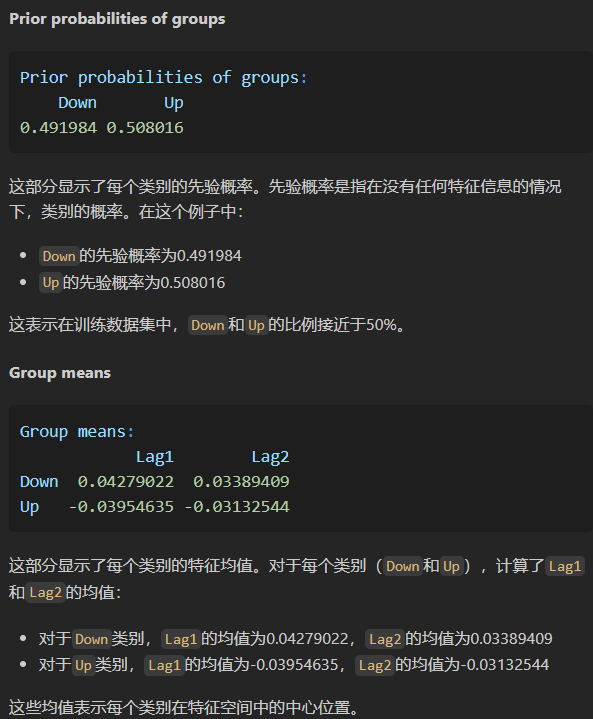
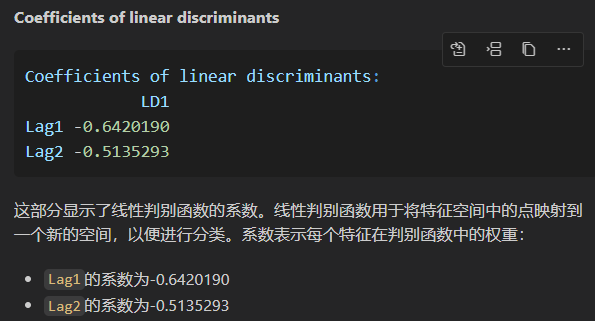

LDA输出表明πˆ1 = 0.492,πˆ2 = 0.508；换句话说，49.2%的训练观测值对应于市场下跌的天数。它还提供了群体均值；这些是每个类中每个预测器的平均值，并被LDA用作µk的估计值。

这表明，在市场上涨的日子里，前两天的收益有为负的趋势，而在市场下跌的日子里，前几天的收益有为正的趋势。

线性判别器输出的系数提供了Lag1和Lag2的线性组合，用于形成LDA决策规则。

换句话说，这些是（4.24）中X = x元素的乘数。如果−0.642 × Lag1−0.514 × Lag2较大，则LDA分类器预测市场增加，如果较小，则LDA分类器预测市场下降。
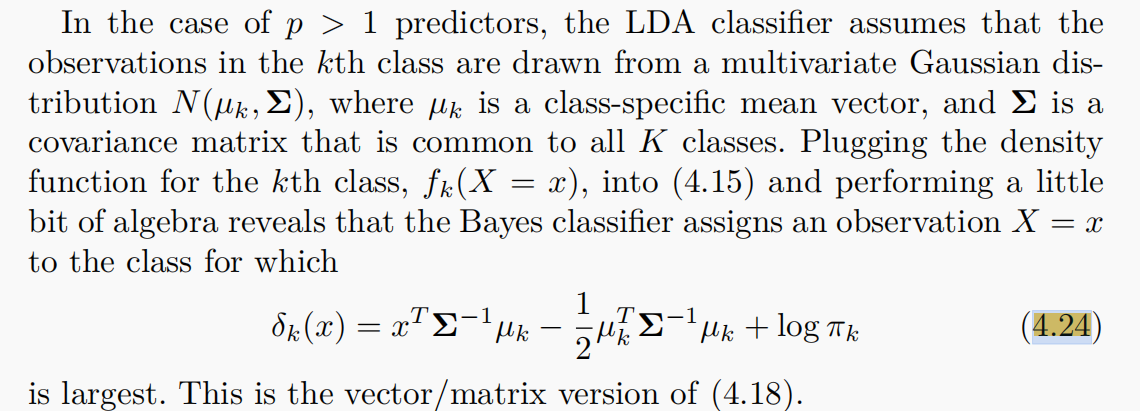

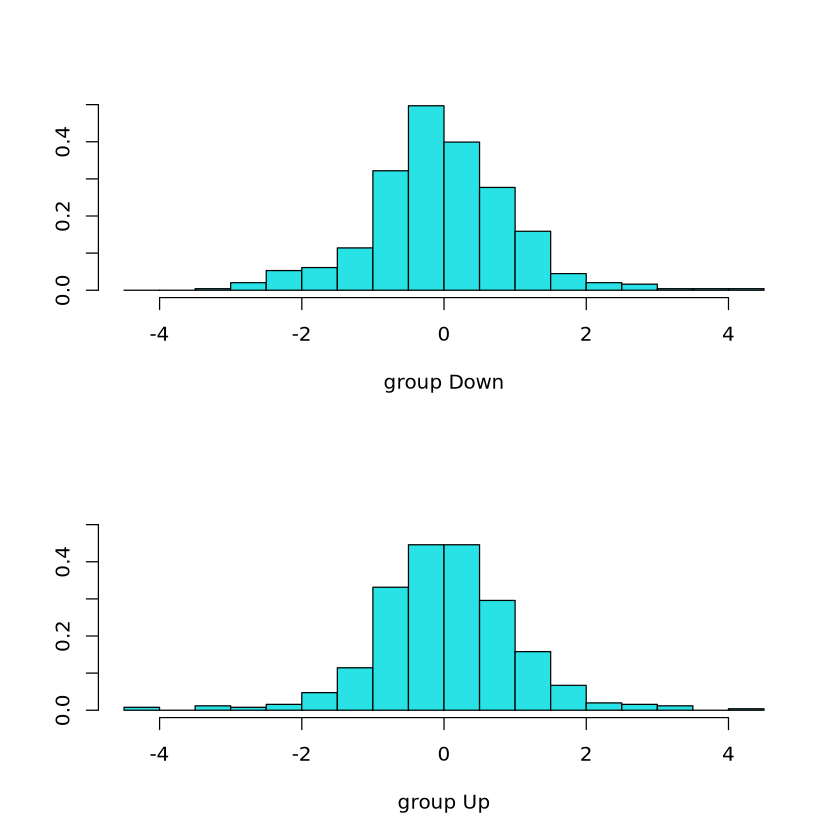

In [46]:
plot(lda.fit)

plot（）函数产生线性判别函数的图，通过计算每个训练观测值的−0.642 × Lag1−0.514 × Lag2得到。上下观察值分别显示

predict() 函数的作用是：返回一个包含三个元素的列表。第一个元素，class，包含了LDA对市场走势的预测。第二个元素，后验，是一个矩阵，它的第k列包含了对应的观测物属于第k类的后验概率，由（4.15）计算。最后，x包含前面描述的线性判别函数。

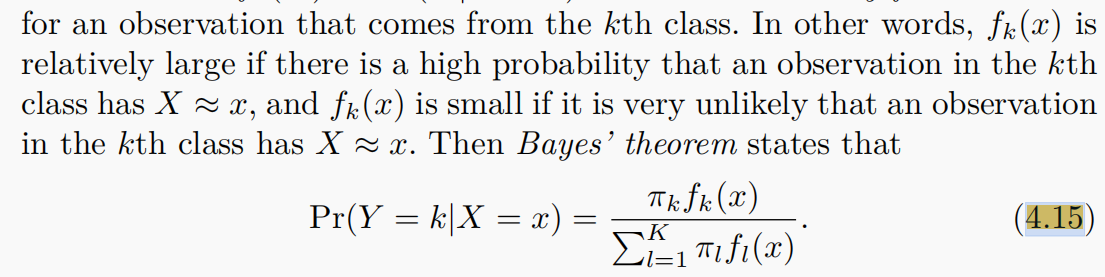

In [ ]:
lda.pred <- predict(lda.fit, Smarket.2005)  # 测试集上的预测结果
names(lda.pred)
lda.pred

[1] "class"     "posterior" "x"

,Down,Up
999,0.4901792,0.5098208
1000,0.4792185,0.5207815
1001,0.4668185,0.5331815
1002,0.4740011,0.5259989
1003,0.4927877,0.5072123
1004,0.4938562,0.5061438
1005,0.4951016,0.5048984
1006,0.4872861,0.5127139
1007,0.4907013,0.5092987
1008,0.4844026,0.5155974


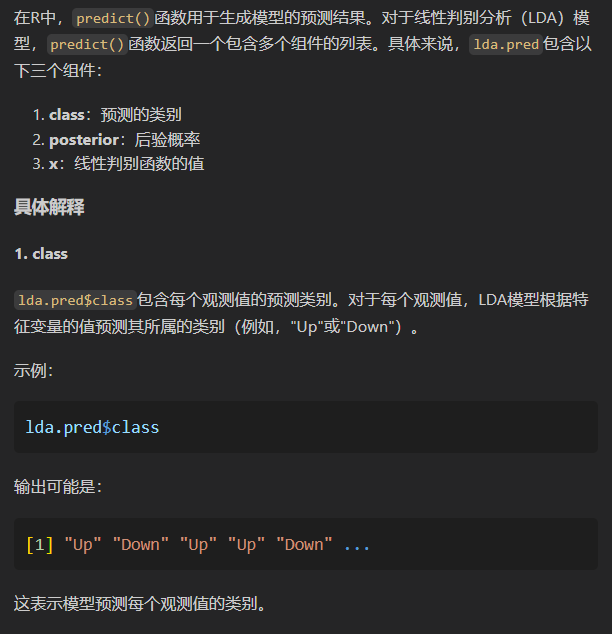

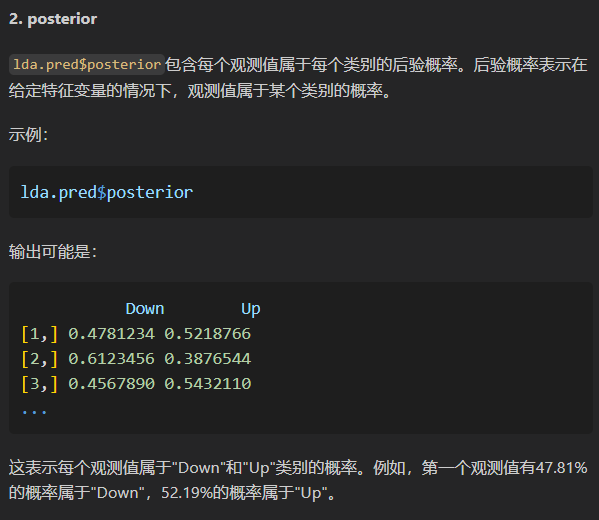

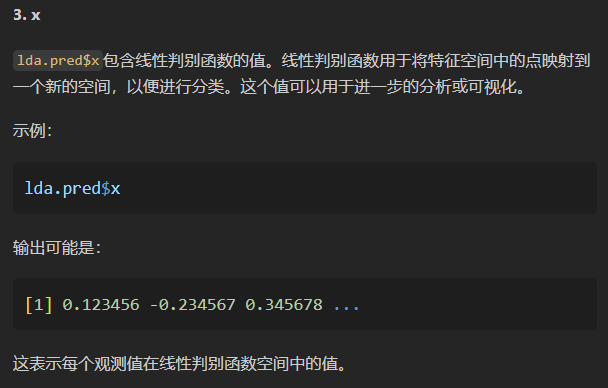

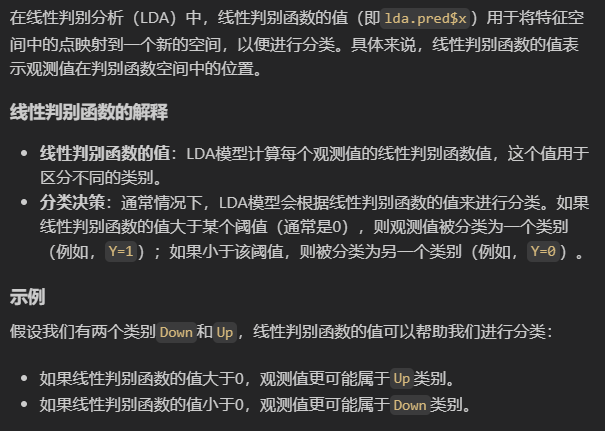

正如我们在4.5节中观察到的，LDA和逻辑回归预测几乎是相同的。

In [49]:
lda.class <- lda.pred$class
table(lda.class, Direction.2005)
mean(lda.class == Direction.2005)

         Direction.2005
lda.class Down  Up
     Down   35  35
     Up     76 106

[1] 0.5595238

In [51]:
# 对后验概率应用50%的阈值使我们能够重新创建包含在lda.pred$类中的预测。
lda.pred$posterior[, 1] #Down的概率
sum(lda.pred$posterior[, 1] >= .5)
sum(lda.pred$posterior[, 1] < .5)

999      1000      1001      1002      1003      1004      1005      1006 
0.4901792 0.4792185 0.4668185 0.4740011 0.4927877 0.4938562 0.4951016 0.4872861 
     1007      1008      1009      1010      1011      1012      1013      1014 
0.4907013 0.4844026 0.4906963 0.5119988 0.4895152 0.4706761 0.4744593 0.4799583 
     1015      1016      1017      1018      1019      1020      1021      1022 
0.4935775 0.5030894 0.4978806 0.4886331 0.5006568 0.5108735 0.5039925 0.4916335 
     1023      1024      1025      1026      1027      1028      1029      1030 
0.5041772 0.5026751 0.4914043 0.4805964 0.4882718 0.5062187 0.5005996 0.4972965 
     1031      1032      1033      1034      1035      1036      1037      1038 
0.4958546 0.4811777 0.4841417 0.4726388 0.4836418 0.5091007 0.5135941 0.4933839 
     1039      1040      1041      1042      1043      1044      1045      1046 
0.4926856 0.4978472 0.4920914 0.5056346 0.5062288 0.4881894 0.4725293 0.4832339 
     1047      1048      1049      1050      1051      1052      1053      1054 
0.4835086 0.4913334 0.4877566 0.4724386 0.4854877 0.4932911 0.4845973 0.4723718 
     1055      1056      1057      1058      1059      1060      1061      1062 
0.4816170 0.4914067 0.4942755 0.4841232 0.5026064 0.5062557 0.4821800 0.4885263 
     1063      1064      1065      1066      1067      1068      1069      1070 
0.5011825 0.5000595 0.5027377 0.4870086 0.4827213 0.4996501 0.4818079 0.4651057 
     1071      1072      1073      1074      1075      1076      1077      1078 
0.4577867 0.4775004 0.5034250 0.4801664 0.5046171 0.5044752 0.4964663 0.4892965 
     1079      1080      1081      1082      1083      1084      1085      1086 
0.4876236 0.4805625 0.4958518 0.5115212 0.4958572 0.5082871 0.5022091 0.4875892 
     1087      1088      1089      1090      1091      1092      1093      1094 
0.4995948 0.4841917 0.4858843 0.4826969 0.4745012 0.5008540 0.5127766 0.5135472 
     1095      1096      1097      1098      1099      1100      1101      1102 
0.5095127 0.4950201 0.4956088 0.4964643 0.4874363 0.4970339 0.5003751 0.4846137 
     1103      1104      1105      1106      1107      1108      1109      1110 
0.4976914 0.5043081 0.4843366 0.4860664 0.4930417 0.4887219 0.4968147 0.4944989 
     1111      1112      1113      1114      1115      1116      1117      1118 
0.4924743 0.4980141 0.4978727 0.4994390 0.5028317 0.4964503 0.4883202 0.4899801 
     1119      1120      1121      1122      1123      1124      1125      1126 
0.4771957 0.4694030 0.4824692 0.5037943 0.5000974 0.4805303 0.4876953 0.5070782 
     1127      1128      1129      1130      1131      1132      1133      1134 
0.4901776 0.4860999 0.5108497 0.5135547 0.5020218 0.4956830 0.4965536 0.4964590 
     1135      1136      1137      1138      1139      1140      1141      1142 
0.4855719 0.4951439 0.5060048 0.4880643 0.4921175 0.4927195 0.4901661 0.5001986 
     1143      1144      1145      1146      1147      1148      1149      1150 
0.5047746 0.4875267 0.4847648 0.5028405 0.5008435 0.4825591 0.4732124 0.4797731 
     1151      1152      1153      1154      1155      1156      1157      1158 
0.4983172 0.4968824 0.4997031 0.4914721 0.4892300 0.4787694 0.4799234 0.4913818 
     1159      1160      1161      1162      1163      1164      1165      1166 
0.4916287 0.4948795 0.4890900 0.4790944 0.4878531 0.4861838 0.4935558 0.4941329 
     1167      1168      1169      1170      1171      1172      1173      1174 
0.5020762 0.5043051 0.4890430 0.5062006 0.5092767 0.4893670 0.4987776 0.4997456 
     1175      1176      1177      1178      1179      1180      1181      1182 
0.4806852 0.4790536 0.4889496 0.5039466 0.4934174 0.4748985 0.4706261 0.4868978 
     1183      1184      1185      1186      1187      1188      1189      1190 
0.4967554 0.4929449 0.4922853 0.4933690 0.5053601 0.5030552 0.4905837 0.4762390 
     1191      1192      1193      1194      1195      1196      1197      1198 
0.4603392 0.4697932 0.4925300 0.48611

[1] 70

[1] 182

注意，模型输出的后验概率对应于市场下降的概率：

In [52]:
lda.pred$posterior[1:20, 1]
lda.class[1:20]

999      1000      1001      1002      1003      1004      1005      1006 
0.4901792 0.4792185 0.4668185 0.4740011 0.4927877 0.4938562 0.4951016 0.4872861 
     1007      1008      1009      1010      1011      1012      1013      1014 
0.4907013 0.4844026 0.4906963 0.5119988 0.4895152 0.4706761 0.4744593 0.4799583 
     1015      1016      1017      1018 
0.4935775 0.5030894 0.4978806 0.4886331

[1] Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Down Up   Up   Up  
[16] Up   Up   Down Up   Up  
Levels: Down Up

如果我们想使用50%以外的后验概率阈值来进行预测，那么我们很容易做到这一点。例如，假设我们希望预测市场下跌，只有当我们非常确定市场确实会下跌的那一天，假设，如果后验概率至少是90%。

In [53]:
sum(lda.pred$posterior[, 1] > .9)

[1] 0

3，Quadratic Discriminant Analysis 二次判别分析

我们现在将QDA模型适配Smarket数据。QDA在R中使用QDA（）函数实现，它也是MAss库的一部分。其语法与lda（）相同。

In [8]:
qda.fit <- qda(Direction ~ Lag1 + Lag2, data = Smarket,subset = train)
qda.fit 

Call:
qda(Direction ~ Lag1 + Lag2, data = Smarket, subset = train)

Prior probabilities of groups:
    Down       Up 
0.491984 0.508016 

Group means:
            Lag1        Lag2
Down  0.04279022  0.03389409
Up   -0.03954635 -0.03132544

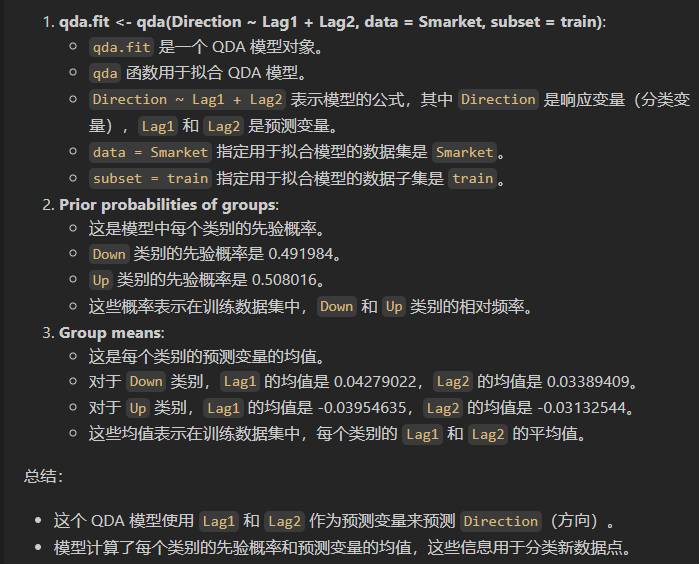

In [13]:
predict(qda.fit, Smarket.2005)
names(predict(qda.fit, Smarket.2005))

,Down,Up
999,0.4873243,0.5126757
1000,0.4759011,0.5240989
1001,0.4636911,0.5363089
1002,0.4739253,0.5260747
1003,0.4903426,0.5096574
1004,0.4913561,0.5086439
1005,0.4922951,0.5077049
1006,0.4847447,0.5152553
1007,0.4889595,0.5110405
1008,0.4818971,0.5181029


[1] "class"     "posterior"

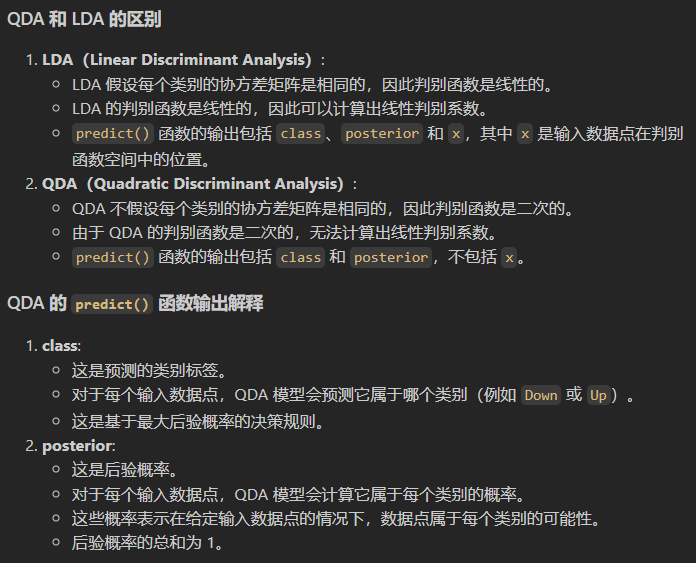

输出包含组的均值。但它不包含线性判别器的系数，因为QDA分类器涉及预测因子的二次函数，而不是线性函数。predict（）函数的工作方式与LDA完全相同。

In [11]:
qda.class <- predict(qda.fit, Smarket.2005)$class  # 上面的代码返回的是一个list，我们需要的是list中的class元素，也就是测试集上的预测结果
table(qda.class, Direction.2005)
mean(qda.class == Direction.2005)

         Direction.2005
qda.class Down  Up
     Down   30  20
     Up     81 121

[1] 0.5992063

有趣的是，尽管2005年的数据没有被用于模型，QDA的预测在60%的时间里是准确的。这种水平的准确性对于股票市场数据来说是相当令人印象深刻的，众所周知，股票市场数据很难建立准确的模型。这表明，QDA所假设的二次形式比LDA和logistic回归所假设的线性形式更能准确地捕捉到真实的关系。然而，我们建议在打赌这种方法将持续击败市场之前，在一个更大的测试集上评估这种方法的性能！

4，Naive Bayes 朴素贝叶斯

接下来，我们用朴素贝叶斯模型来拟合Smarker数据。朴素贝叶斯是在R中使用naiveBayes（）函数实现的，它是e1071库的一部分。语法与lda（）和qda（）相同。默认情况下，朴素贝叶斯分类器的这种实现使用高斯分布为每个定量特征建模。然而，核密度方法也可以用来估计分布。

In [15]:
library(e1071)
nb.fit <- naiveBayes(Direction ~ Lag1 + Lag2, data = Smarket,subset = train)
nb.fit


Naive Bayes Classifier for Discrete Predictors

Call:
naiveBayes.default(x = X, y = Y, laplace = laplace)

A-priori probabilities:
Y
    Down       Up 
0.491984 0.508016 

Conditional probabilities:
      Lag1
Y             [,1]     [,2]
  Down  0.04279022 1.227446
  Up   -0.03954635 1.231668

      Lag2
Y             [,1]     [,2]
  Down  0.03389409 1.239191
  Up   -0.03132544 1.220765


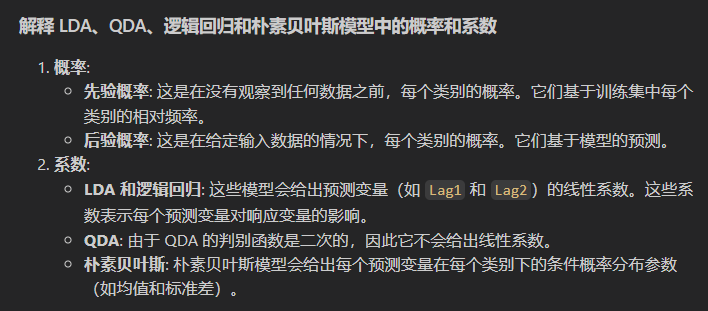

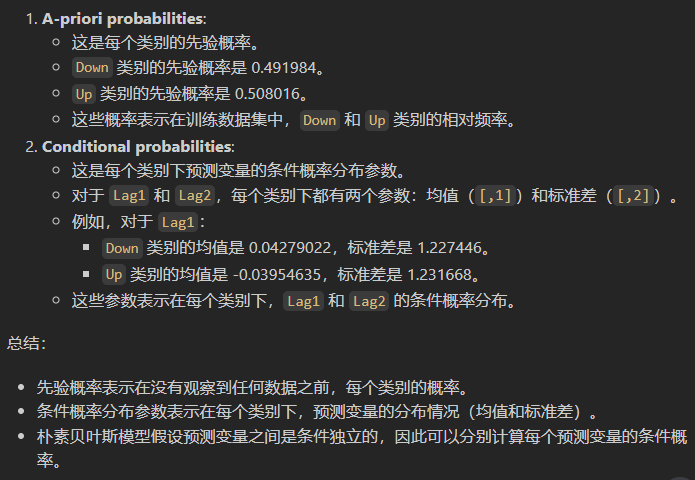

输出包含每个类中每个变量的估计平均值和标准偏差。例如，当Direction=Down时，Lag1的平均值为0.0428，标准差为1.23。我们可以很容易地验证：

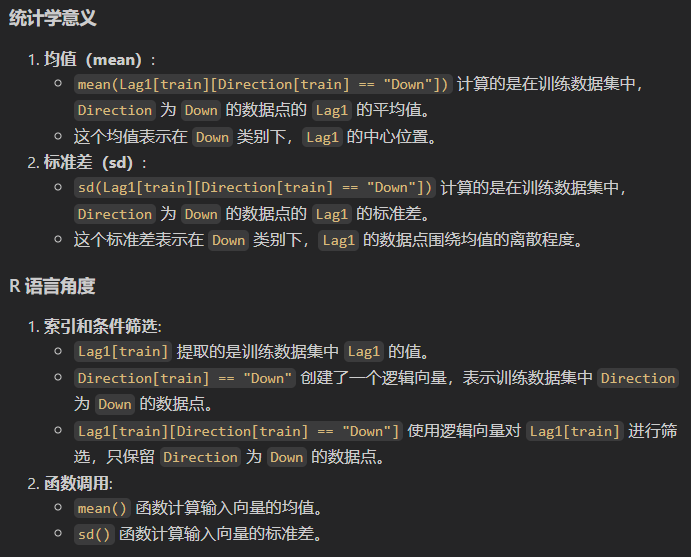

In [20]:
mean(Lag1[train][Direction[train] == "Down"])
sd(Lag1[train][Direction[train] == "Down"])

[1] 0.04279022

[1] 1.227446

In [ ]:
# 然后就是predict函数
nb.class <- predict(nb.fit, Smarket.2005)
nb.class
# names(nb.class)
table(nb.class, Direction.2005)
mean(nb.class == Direction.2005)

[1] Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Down Up   Up   Up  
 [16] Up   Up   Down Up   Up   Up   Down Down Up   Down Down Up   Up   Up   Down
 [31] Up   Up   Up   Up   Up   Up   Up   Down Down Up   Up   Up   Up   Down Down
 [46] Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up  
 [61] Up   Down Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Down
 [76] Up   Down Down Up   Up   Up   Up   Up   Down Up   Down Down Up   Up   Up  
 [91] Up   Up   Up   Up   Down Down Down Up   Up   Up   Up   Up   Up   Up   Up  
[106] Down Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up  
[121] Up   Up   Up   Down Up   Up   Up   Down Up   Up   Down Down Up   Up   Up  
[136] Up   Up   Up   Down Up   Up   Up   Up   Up   Down Up   Up   Up   Up   Up  
[151] Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up   Up  
[166] Up   Up   Up   Up   Down Up   Down Down Up   Up   Up   Up   Up   Up   Down
[181] Up   Up   Up   Up   Up   Up   Up   Up   Down Down Up   Up   Up   Up   Up  
[196] Up   Up   Up   Up   Up   Down Up   Up   Up   Up   Down Down Up   Up   Down
[211] Down Up   Up   Down Up   Up   Up   Up   Down Down Up   Up   Up   Down Down
[226] Down Down Up   Up   Up   Up   Up   Up   Down Up   Up   Up   Up   Up   Up  
[241] Up   Down Up   Up   Up   Up   Up   Up   Up   Up   Up   Up  
Levels: Down Up

NULL

        Direction.2005
nb.class Down  Up
    Down   28  20
    Up     83 121

[1] 0.5912698

朴素贝叶斯在这些数据上的表现非常好，预测准确率超过59%。这比QDA略差，但比LDA好得多。

predict（）函数还可以生成每个观测结果属于特定类的概率估计值。

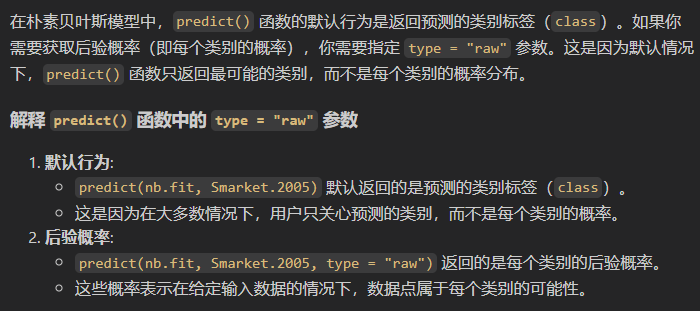

In [25]:
nb.preds <- predict(nb.fit, Smarket.2005, type = "raw")
nb.preds[1:5, ]

Down,Up
0.4873164,0.5126836
0.4762492,0.5237508
0.4653377,0.5346623
0.4748652,0.5251348
0.4901890,0.5098110


5，K-Nearest Neighbors KNN-K近邻


现在我们将使用KNN（）函数来执行KNN，它是class库的一部分。

该函数的工作方式与我们迄今为止遇到的其他模型拟合函数非常不同。knn（）不是先拟合模型，然后使用模型进行预测的两步方法，而是使用单个命令形成预测。

该函数需要4个输入：

1，一个包含与训练数据相关联的预测因子的矩阵，标记为下面的train.X——》很好理解，就是train集的feature，train x

2，一个矩阵，包含与我们想要进行预测的数据相关联的预测因子，标记为下面的test.X——》很好理解，就是test集的feature，test x

3，一个包含训集练观察值的class标签的向量，标记为下面的train.Direction——》很好理解，就是train集的label，train y

4，K的值，分类器使用的最近邻居的数量

我们使用cbind（）函数，即column bind的缩写，将Lag1和Lag2变量绑定到两个矩阵中，一个用于训练集，另一个用于测试集。

In [ ]:
cbind(Lag1, Lag2) # matrix
# Smarket[,c("Lag1","Lag2")] data.frame，当然获取数据实际上是一样的，也可以使用tidyverse

Lag1,Lag2
0.381,-0.192
0.959,0.381
1.032,0.959
-0.623,1.032
0.614,-0.623
0.213,0.614
1.392,0.213
-0.403,1.392
0.027,-0.403
1.303,0.027


In [31]:
library(class)
train.X <- cbind(Lag1, Lag2)[train, ]   # train是一个逻辑向量，用来获取训练集的数据，行的逻辑索引
test.X <- cbind(Lag1, Lag2)[!train, ]    # !train是一个逻辑向量，用来获取测试集的数据，行的逻辑索引
train.Direction <- Direction[train]      # 获取训练集的y

现在knn（）函数可以用来预测2005年的市场运动。我们在应用knn（）之前设置了一个随机种子，因为如果几个观测与最近的邻居相关联，那么R将随机打破这个关联。因此，为了确保结果的可重复性，必须设置种子。

In [33]:
?knn

knn                   package:class                    R Documentation

_k-_N_e_a_r_e_s_t _N_e_i_g_h_b_o_u_r _C_l_a_s_s_i_f_i_c_a_t_i_o_n

_D_e_s_c_r_i_p_t_i_o_n:

     k-nearest neighbour classification for test set from training set.
     For each row of the test set, the ‘k’ nearest (in Euclidean
     distance) training set vectors are found, and the classification
     is decided by majority vote, with ties broken at random. If there
     are ties for the ‘k’th nearest vector, all candidates are included
     in the vote.

_U_s_a_g_e:

     knn(train, test, cl, k = 1, l = 0, prob = FALSE, use.all = TRUE)
     
_A_r_g_u_m_e_n_t_s:

   train: matrix or data frame of training set cases.

    test: matrix or data frame of test set cases. A vector will be
          interpreted as a row vector for a single case.

      cl: factor of true classifications of training set

       k: number of neighbours considered.

       l: minimum v

In [ ]:
set.seed(1)
knn.pred <- knn(train.X, test.X, train.Direction, k = 1)
knn.pred  # 我们可以发现knn.pred只有class，没有posterior，因为knn是一个非概率模型，它只能给出一个类别，而不能给出后验概率

[1] Up   Down Up   Up   Up   Down Down Down Down Up   Up   Up   Up   Up   Down
 [16] Down Up   Up   Up   Up   Down Down Down Down Down Up   Up   Up   Down Up  
 [31] Up   Down Up   Down Up   Up   Up   Up   Down Up   Up   Up   Down Down Down
 [46] Down Up   Down Up   Up   Down Up   Down Down Up   Up   Up   Down Up   Up  
 [61] Up   Up   Up   Up   Down Down Down Up   Up   Up   Up   Down Up   Down Down
 [76] Down Up   Up   Up   Down Up   Up   Down Down Up   Up   Up   Up   Down Up  
 [91] Up   Up   Up   Down Down Up   Up   Up   Up   Down Down Down Up   Up   Up  
[106] Up   Down Down Down Down Up   Up   Up   Up   Up   Down Up   Up   Down Up  
[121] Up   Up   Down Up   Down Down Up   Up   Down Down Down Down Up   Down Up  
[136] Down Up   Up   Up   Down Up   Down Up   Down Down Up   Up   Down Up   Up  
[151] Down Up   Up   Up   Up   Up   Up   Down Up   Down Up   Down Up   Down Up  
[166] Up   Up   Down Up   Up   Up   Up   Down Up   Down Up   Up   Down Down Up  
[181] Down Down Up   Up   Down Up   Up   Down Up   Up   Down Down Up   Down Up  
[196] Up   Up   Down Down Down Up   Up   Up   Up   Down Up   Down Down Up   Up  
[211] Up   Down Up   Up   Up   Down Up   Down Up   Up   Up   Up   Up   Up   Up  
[226] Down Down Up   Down Up   Up   Up   Down Up   Up   Down Down Up   Down Down
[241] Up   Up   Down Up   Down Up   Down Down Down Up   Down Up  
Levels: Down Up

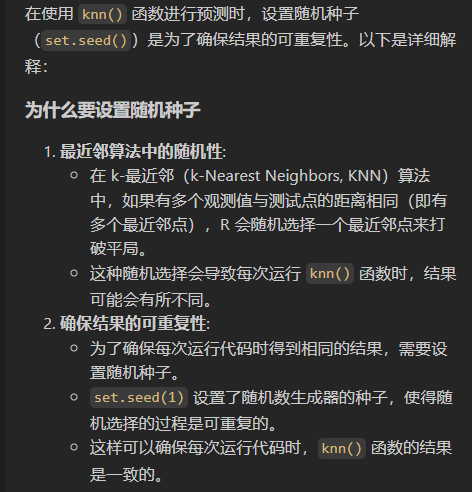

In [36]:
table(knn.pred, Direction.2005)
mean(knn.pred == Direction.2005)

        Direction.2005
knn.pred Down Up
    Down   43 58
    Up     68 83

[1] 0.5

使用K = 1的结果不是很好，因为只有50%的观察被正确预测。当然，K = 1可能导致数据过于灵活地拟合。下面，我们使用K = 3重复分析。

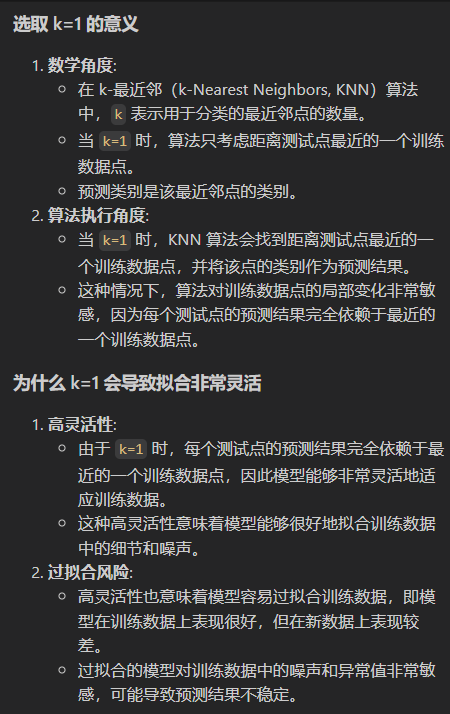

In [37]:
knn.pred <- knn(train.X, test.X, train.Direction, k = 3)
table(knn.pred, Direction.2005)
mean(knn.pred == Direction.2005)

        Direction.2005
knn.pred Down Up
    Down   48 54
    Up     63 87

[1] 0.5357143

结果略有改善。但是进一步增加K并不能提供进一步的改善。对于这一数据，QDA提供了我们目前所研究的方法中最好的结果。

KNN在Smarket数据上表现不佳，但它经常提供令人印象深刻的结果。作为一个例子，我们将把KNN方法应用于作为ISLR2库一部分的Caravan数据集。该数据集包括测量5,822人人口统计学特征的85个预测因素。响应变量是Purchase，它表示给定的个人是否购买商队保险政策。在这个数据集中，只有6%的人购买了商队保险。

In [40]:
dim(Caravan)
attach(Caravan)
head(Caravan)
summary(Purchase)

[1] 5822   86

The following objects are masked from Caravan (pos = 3):

    AAANHANG, ABESAUT, ABRAND, ABROM, ABYSTAND, AFIETS, AGEZONG,
    AINBOED, ALEVEN, AMOTSCO, APERSAUT, APERSONG, APLEZIER, ATRACTOR,
    AVRAAUT, AWABEDR, AWALAND, AWAOREG, AWAPART, AWERKT, AZEILPL,
    MAANTHUI, MAUT0, MAUT1, MAUT2, MBERARBG, MBERARBO, MBERBOER,
    MBERHOOG, MBERMIDD, MBERZELF, MFALLEEN, MFGEKIND, MFWEKIND,
    MGEMLEEF, MGEMOMV, MGODGE, MGODOV, MGODPR, MGODRK, MHHUUR, MHKOOP,
    MINK123M, MINK3045, MINK4575, MINK7512, MINKGEM, MINKM30, MKOOPKLA,
    MOPLHOOG, MOPLLAAG, MOPLMIDD, MOSHOOFD, MOSTYPE, MRELGE, MRELOV,
    MRELSA, MSKA, MSKB1, MSKB2, MSKC, MSKD, MZFONDS, MZPART, PAANHANG,
    PBESAUT, PBRAND, PBROM, PBYSTAND, PFIETS, PGEZONG, PINBOED, PLEVEN,
    PMOTSCO, PPERSAUT, PPERSONG, PPLEZIER, PTRACTOR, Purchase, PVRAAUT,
    PWABEDR, PWALAND, PWAOREG, PWAPART, PWERKT, PZEILPL




,MOSTYPE,MAANTHUI,MGEMOMV,MGEMLEEF,MOSHOOFD,MGODRK,MGODPR,MGODOV,MGODGE,MRELGE,⋯,APERSONG,AGEZONG,AWAOREG,ABRAND,AZEILPL,APLEZIER,AFIETS,AINBOED,ABYSTAND,Purchase
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,33,1,3,2,8,0,5,1,3,7,⋯,0,0,0,1,0,0,0,0,0,No
2,37,1,2,2,8,1,4,1,4,6,⋯,0,0,0,1,0,0,0,0,0,No
3,37,1,2,2,8,0,4,2,4,3,⋯,0,0,0,1,0,0,0,0,0,No
4,9,1,3,3,3,2,3,2,4,5,⋯,0,0,0,1,0,0,0,0,0,No
5,40,1,4,2,10,1,4,1,4,7,⋯,0,0,0,1,0,0,0,0,0,No
6,23,1,2,1,5,0,5,0,5,0,⋯,0,0,0,0,0,0,0,0,0,No


No  Yes 
5474  348

因为KNN分类器通过识别最接近的观测来预测给定测试观测的类别，变量的规模很重要。与小尺度的变量相比，大尺度的变量将对观测之间的距离产生更大的影响，从而对KNN分类器产生更大的影响。例如，假设有一个包含两个变量的数据集，工资和年龄（分别以美元和年份衡量）。就KNN而言，与50岁的年龄差距相比，1000美元的工资差距是巨大的。因此，工资将驱动KNN分类结果，而年龄将几乎没有影响。这与我们的直觉相反，我们认为1000美元的工资差异与50岁的年龄差异相比是相当小的。此外，规模对KNN分类器的重要性导致了另一个问题：如果我们用日元来衡量工资，或者用分钟来衡量年龄，那么我们得到的分类结果就会与用美元和年来衡量这两个变量得到的分类结果完全不同。

处理这个问题的一个好方法是将数据标准化，使所有变量的平均值为0，标准差为1。那么所有的变量都将在一个可比的尺度上。scale（）函数的作用就是这样。在标准化数据时，我们排除了第86列，因为那是定性的Purchase变量。

In [41]:
?scale

scale                   package:base                   R Documentation

_S_c_a_l_i_n_g _a_n_d _C_e_n_t_e_r_i_n_g _o_f _M_a_t_r_i_x-_l_i_k_e _O_b_j_e_c_t_s

_D_e_s_c_r_i_p_t_i_o_n:

     ‘scale’ is generic function whose default method centers and/or
     scales the columns of a numeric matrix.

_U_s_a_g_e:

     scale(x, center = TRUE, scale = TRUE)
     
_A_r_g_u_m_e_n_t_s:

       x: a numeric matrix(like object).

  center: either a logical value or numeric-alike vector of length
          equal to the number of columns of ‘x’, where ‘numeric-alike’
          means that ‘as.numeric(.)’ will be applied successfully if
          ‘is.numeric(.)’ is not true.

   scale: either a logical value or a numeric-alike vector of length
          equal to the number of columns of ‘x’.

_D_e_t_a_i_l_s:

     The value of ‘center’ determines how column centering is
     performed.  If ‘center’ is a numeric-alike vector with leng

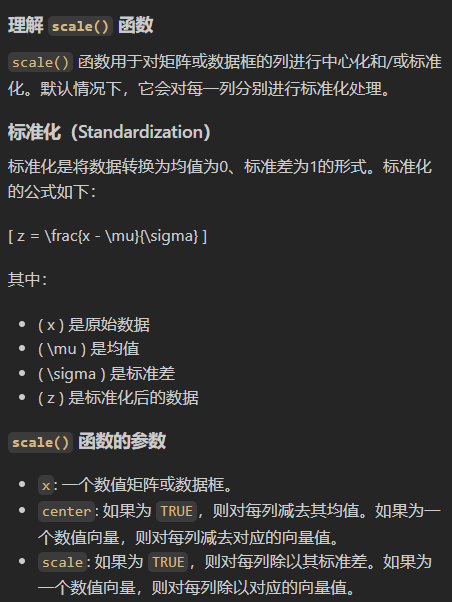

In [47]:
standardized.X <- scale(Caravan[, -86])

# 比较标准化之前和标准化之后的数据
var(Caravan[, 1])  # 未标准化的第一个变量的方差
var(Caravan[, 2])  # 未标准化的第二个变量的方差

var(standardized.X[, 1])  # 标准化之后的第一个变量的方差
var(standardized.X[, 2])  # 标准化之后的第二个变量的方差

# 同样对于标准化前后的数据，我们可以计算均值
mean(Caravan[, 1])  # 未标准化的第一个变量的均值
mean(Caravan[, 2])  # 未标准化的第二个变量的均值

mean(standardized.X[, 1])  # 标准化之后的第一个变量的均值   
mean(standardized.X[, 2])  # 标准化之后的第二个变量的均值


[1] 165.0378

[1] 0.1647078

[1] 1

[1] 1

[1] 24.25335

[1] 1.110615

[1] -7.025576e-17

[1] -1.470838e-16

现在standardized.X的每一列的标准差为1，均值为0。

方差方面我们检查了scale之后的第1列以及第2类，是符合方差为1的；但是均值方面我们检查之后并不是这样

也许是是因为出现了NA也就是缺失值



In [53]:
# 检查数据中是否存在缺失值
sum(is.na(Caravan)) # 0，并不存在缺失值
sum(is.na(standardized.X)) # 0

Caravan[, 1]
standardized.X[, 1]

mean(Caravan[, 1])  
mean(standardized.X[, 1])

# scale(Caravan[, -86])

[1] 0

[1] 0

[1] 33 37 37  9 40 23 39 33 33 11 10  9 33 41 23 33 38 22 13 31 33 33 13 34
  [25] 13 33 37 40 31 33 24 23 33 38 13  8  7 41 39 33 24 11  8 33  3 38 36 38
  [49] 39 33 33 25 20 11 33 39 11 12 35 30 30 36 34 23 11 33 36 13 36 29  9 25
  [73] 32  8 11  3 38 11  3 13  3  3  1 41 23 38  1 39 36 38  9  8  3 26 39 11
  [97] 39  9 36 24 33  1 33 11 37 24  2 23 37 36  8 23 33 34 33 22 34 33  8 33
 [121] 37 35 34  9 10 30 36  3 25 23  8 37 38  8  7 29 33 33  1 13 26 13 34 38
 [145] 33 33 31  8 40  8  8  3 38 12 10 37 10 35 32 39 24  9 31 40 41 39 38 37
 [169] 35  9  9 11 41 33 34 29  9  8 33 41 10  9 10  3 33 25 38 38 41 13 33 33
 [193] 31  2 36 39  9 39 35 33 22 35 10 38 12  9 24 11 33  9 22 38 37 36 33 40
 [217] 33 10 13 35 31 22 33 29 24 37 10 11 37 36  4  8 36 31 38  8 31 39 35  8
 [241]  8 10 40 35 39 38  1 33 33 38 39  2 16 38 36 39 23 32 37 33 11 10  4  2
 [265] 22  9  5 26 10  9 36 33 38 25  1 33 23 24 22  9 30  8  3 36 41 41 11  3
 [289] 33  9 34 41 21  3  2 23 30  8 32  9 33  8 39 33 33 36 33 35  1 13 33 16
 [313] 39 13  3 13 33  1 35  8 41 33 33 10 33 35  8 32 39 22 33 29 41 37 16 12
 [337] 38 33 41  6 10 31 33 24 37 41 34  1 35 12 41 36  6 39 23  9  8 34  8 34
 [361] 33  4 41 38 34 32 32 12  9 33  8 31  2 37  9  8 39 32 26 35 35 33 34 33
 [385] 34 18 13 33 37  6 13 35 34 33  2  8 41 33 24 33 31 36 41 34 36 33 11  4
 [409] 34  4 38 38  2  1 38  8  2  8 22 12 30 30  6  4 10 21 38 12 23  3 33 33
 [433] 27 30 38 36  9 36 22  6  6  9  1 27 33 36  9  7 38 33 22  8 16 38  1 35
 [457] 23 38 20 28  3 35 35 29  9 36 33 23  8 33  9 33 38 33 33 35  8 24 27 26
 [481] 32  4  8 33 24  9 30 33  3 33 40  6 27  8 24 24  8 11  5 33 24 33 33 33
 [505] 12 39 38 36 33 40  8  3 33 32 13 39 33 36 23 35 39 25 11 22 35 39  6 31
 [529] 38 31 32  5 24 39  3 33 22 34  1  6 35 33 41 36 25 38 39 33 25  1 39 36
 [553]  3 33 38 33 41 23 29  2  8 23 23  9 24  7  3 33 33 30 34 38 24 23  1  9
 [577]  1 36 33 26  5  1  2  3 16  7 38 39 38 36 32  2 38 31  1 13 34 10 33 38
 [601] 10 40 41 35 24  8 38 33 10 39 36 34 12 34 39 41 38 38 39  3 39 37 32 41
 [625]  9 33 33 31 31 34 34 39  9 33  3 26  9 12 13 22 10 36 22 31 30 13  9 40
 [649]  6 33  3 24 33 32 33 28 37 39 33 33 24  8 38  7 38 28  8  1 31 38 24  1
 [673] 33  6  3 11 33 36  8 27  1 39 12 31  8 41 13 22 39 30 33 24 24 39 35 12
 [697]  4 31 33 13 27 36 12  8 33 13 30 33  7 31 39 31 33 38 31  1 36 13 33 33
 [721] 39 29 31 29 35 33 33 20  8 29 25  3 24 32 32 31 38 31  6 10 25 10 32 37
 [745]  8 31 34  2 25 33 33 24 33 23 30 38 23 38  5 31 34 24 32 39 35 33  2  8
 [769]  9 33 33 33 13 38 23 33 36 11 11 38 35  8 23 11  1  3 13 23  4 37 31 38
 [793] 23 21 31 33 33  8 18  1  8 38 39 10  8 12 30 32 31  9  1  3 40 33  8  8
 [817] 37  3 35 10 37 38 38 38 31  2 37  3 38 33 36 39 39  9 12 33 38  3 41 36
 [841] 27  8 12 22  1 20  8 37 38 33 23 38 29 38 17 11  8 34 23 11 34 24  6 10
 [865] 23  2  8 22  3 33  6 33 36 32 36  6  8 38  8 39 30 38 38 38 33  9 27  2
 [889]  3 32 33 39 36 35 33  6  1 32 23  1 41 31 39 10 23 23 10 33 24 13 33  6
 [913] 36 32  3 28  9 36 40  3 33 36 35 39 11 36 32  8 11  6 33 25 38 38 34 36
 [937] 30 29 23  5 31 13 39 33 11 33  3 35 39 32 24  5 33 39 34 31 24 33  6  2
 [961] 23 39 10 33 23 33 33 40 11 36 22 36  8 30  8 36 30 32 13 33  3  1 31 38
 [985]  1  7 38  5 37 38 38 38 38 40 27 33  1 33  3 33 40 26 10 38 39  9 33 33
[1009] 39 23 39 30  1 35 22 10 33 11 25 41 36 39 38 26 36 39 33  1  8 33 33  2
[1033] 33  3 33  9 33 41 10 35 29 37  3  6 34 10 23 12  3 33 33 31 39 10 11  1
[1057] 29 13  9 33 35  8 41 32 37  8  8 24 34 31 39 33 35 29  7  6  1 34 35 33
[1081] 30  8 36  8  8 37 13 38 39 31 13 37 33 26 11  8 29 35 36 16 23 23 36 39
[1105] 31 39 33 41 34  3  8 38 23 33  9 24  9 33  9  7  3 32 13 30  3 34 29 32
[1129]  2 34 39  9 32 36 12 32  7 23 38 33 23 37 32 38 13 30  8 40 23 40 31 23
[1153] 33 36 39 37 33 38 26  9 22 41 33  8 35 39 11 10 38 17 36 37 33 31 33 10
[1177] 39 23 31 10 33 24 38 39 33  8  6 33 10 33 12 23  8 33 24  8 37 38 39 33
[1201]  2 39  9 33 13  8 33 38  8  1 33  9 12 41 11 3

1           2           3           4           5           6 
 0.68084775  0.99221162  0.99221162 -1.18733547  1.22573452 -0.09756193 
          7           8           9          10          11          12 
 1.14789355  0.68084775  0.68084775 -1.03165354 -1.10949450 -1.18733547 
         13          14          15          16          17          18 
 0.68084775  1.30357549 -0.09756193  0.68084775  1.07005258 -0.17540289 
         19          20          21          22          23          24 
-0.87597160  0.52516581  0.68084775  0.68084775 -0.87597160  0.75868871 
         25          26          27          28          29          30 
-0.87597160  0.68084775  0.99221162  1.22573452  0.52516581  0.68084775 
         31          32          33          34          35          36 
-0.01972096 -0.09756193  0.68084775  1.07005258 -0.87597160 -1.26517644 
         37          38          39          40          41          42 
-1.34301741  1.30357549  1.14789355  0.68084775 -0.01972096 -1.03165354 
         43          44          45          46          47          48 
-1.26517644  0.68084775 -1.65438128  1.07005258  0.91437065  1.07005258 
         49          50          51          52          53          54 
 1.14789355  0.68084775  0.68084775  0.05812001 -0.33108483 -1.03165354 
         55          56          57          58          59          60 
 0.68084775  1.14789355 -1.03165354 -0.95381257  0.83652968  0.44732484 
         61          62          63          64          65          66 
 0.44732484  0.91437065  0.75868871 -0.09756193 -1.03165354  0.68084775 
         67          68          69          70          71          72 
 0.91437065 -0.87597160  0.91437065  0.36948388 -1.18733547  0.05812001 
         73          74          75          76          77          78 
 0.60300678 -1.26517644 -1.03165354 -1.65438128  1.07005258 -1.03165354 
         79          80          81          82          83          84 
-1.65438128 -0.87597160 -1.65438128 -1.65438128 -1.81006321  1.30357549 
         85          86          87          88          89          90 
-0.09756193  1.07005258 -1.81006321  1.14789355  0.91437065  1.07005258 
         91          92          93          94          95          96 
-1.18733547 -1.26517644 -1.65438128  0.13596098  1.14789355 -1.03165354 
         97          98          99         100         101         102 
 1.14789355 -1.18733547  0.91437065 -0.01972096  0.68084775 -1.81006321 
        103         104         105         106         107         108 
 0.68084775 -1.03165354  0.99221162 -0.01972096 -1.73222224 -0.09756193 
        109         110         111         112         113         114 
 0.99221162  0.91437065 -1.26517644 -0.09756193  0.68084775  0.75868871 
        115         116         117         118         119         120 
 0.68084775 -0.17540289  0.75868871  0.68084775 -1.26517644  0.68084775 
        121         122         123         124         125         126 
 0.99221162  0.83652968  0.75868871 -1.18733547 -1.10949450  0.44732484 
        127         128         129         130         131         132 
 0.91437065 -1.65438128  0.05812001 -0.09756193 -1.26517644  0.99221162 
        133         134         135         136         137         138 
 1.07005258 -1.26517644 -1.34301741  0.36948388  0.68084775  0.68084775 
        139         140         141         142         143         144 
-1.81006321 -0.87597160  0.13596098 -0.87597160  0.75868871  1.07005258 
        145         146         147         148         149         150 
 0.68084775  0.68084775  0.52516581 -1.26517644  1.22573452 -1.26517644 
        151         152         153         154         155         156 
-1.26517644 -1.65438128  1.07005258 -0.95381257 -1.10949450  0.99221162 
        157         158         159         160         161         162 
-1.10949450  0.83652968  0.60300678  1.14789355 -0.01972096 -1.18733547 
        163         164         165         166         167         

[1] 24.25335

[1] -7.025576e-17

In [55]:
mean(standardized.X[, 1])

sum(standardized.X[, 1])/length(standardized.X[, 1])

[1] -7.025576e-17

[1] -7.030666e-17

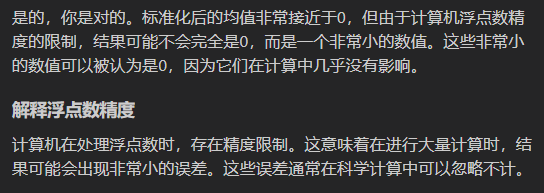

可以发现不是NA缺失值的问题，应该是浮点数计算的精度问题，总之可以认为scale默认的就是对每一列，对每一个预测变量，每一个feature进行了标准化

现在，我们将观测数据分成一个测试集（包含前1,000个观测数据）和一个训练集（包含其余观测数据）。我们使用K = 1在训练数据上建立了KNN模型，并在测试数据上评价了该模型的性能。

In [ ]:
test <- 1:1000 # 行索引
train.X <- standardized.X[-test, ]
test.X <- standardized.X[test, ]
train.Y <- Purchase[-test]
test.Y <- Purchase[test]
    
set.seed(1)
knn.pred <- knn(train.X, test.X, train.Y, k = 1)
mean(test.Y != knn.pred)
mean(test.Y != "No")

[1] 0.118

[1] 0.059

在1000次测试观察中KNN错误率略低于12%。乍一看，这似乎相当不错。然而，由于只有6%的客户购买了保险，我们可以通过总是预测No将错误率降低到6%，无论预测器的值是多少！——》所以数据有问题？

假设有一些非微不足道的成本试图出售保险给一个特定的人。例如，也许销售人员必须拜访每个潜在客户。如果该公司试图向随机选择的客户销售保险，那么成功率将只有6%，考虑到所涉及的成本，这可能太低了。相反，该公司希望只向可能购买保险的客户销售保险。所以总体的错误率并不重要。相反，被正确预测会购买保险的个人比例值得关注——》从数据的反面看问题！

In [ ]:
table(knn.pred, test.Y)
# mean(knn.pred == test.Y)
9 / (68 + 9)  # 预测为Yes的准确率，预测会购买的数目中，实际购买的数目占比（注意我们要估计模型的效果，都是从模型的角度出发，所以我们要计算预测为Yes的准确率）

        test.Y
knn.pred  No Yes
     No  873  50
     Yes  68   9

[1] 0.1168831

结果表明，K = 1的KNN在预测购买保险的顾客中比随机猜测的效果好得多。在77个这样的客户中，有9个（11.7%）确实购买了保险。这是随机猜测的两倍。

至于这里为什么说是随机猜测的两倍多的概率，那么随机猜测又指的是什么，很简答，随机猜测指的就是训练集中先验概率，就是实际的比例，我们可以发现训练集中的购买yes的比例在5.9%左右，所以我们用k=1的knn在测试集上的预测准确率是随机猜测的两倍左右。

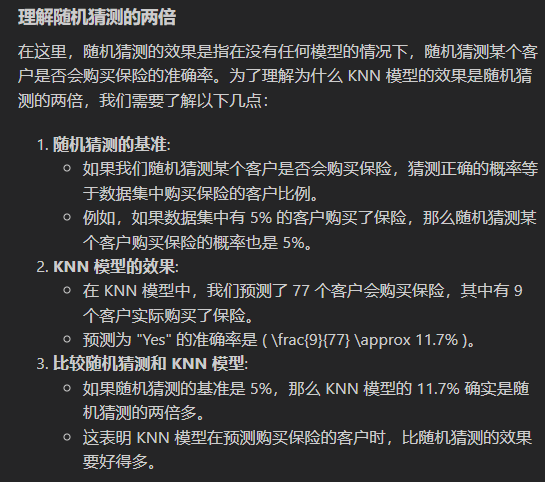

In [ ]:
summary(Caravan$Purchase)
348/(348+5474)  

No  Yes 
5474  348

[1] 0.05977327

In [63]:
knn.pred <- knn(train.X, test.X, train.Y, k = 3)
table(knn.pred, test.Y) 
5 / 26

knn.pred <- knn(train.X, test.X, train.Y, k = 5)
table(knn.pred, test.Y)
4 / 15

        test.Y
knn.pred  No Yes
     No  920  54
     Yes  21   5

[1] 0.1923077

        test.Y
knn.pred  No Yes
     No  930  55
     Yes  11   4

[1] 0.2666667

K = 3时，成功率为19%，K = 5时成功率为26.7%。这是随机猜测率的四倍多。看来KNN在一个困难的数据集中找到了一些真实的模式！

越复杂的数据，knn的效果越好，不不同于前面的数据

然而，虽然这一策略具有成本效益，但值得注意的是，使用K = 5的KNN，预计只有15名客户购买保险。在实践中，保险公司可能希望花费资源说服15个以上的潜在客户购买保险。

In [66]:
glm.fits <- glm(Purchase ~ ., data = Caravan,family = binomial, subset = -test)
glm.probs <- predict(glm.fits, Caravan[test, ],type = "response")
glm.pred <- ifelse(glm.probs > 0.5,"Yes","No")
table(glm.pred, test.Y)

# 0.5阈值下的准确率并不好，我们可以调整阈值
glm.pred <- ifelse(glm.probs > 0.25,"Yes","No")
table(glm.pred, test.Y)

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


        test.Y
glm.pred  No Yes
     No  934  59
     Yes   7   0

        test.Y
glm.pred  No Yes
     No  919  48
     Yes  22  11

作为比较，我们还可以对数据拟合逻辑回归模型。如果我们使用0.5作为分类器的预测概率截断值，那么我们就有一个问题：只有7个测试观察值被预测购买保险。更糟糕的是，所有这些7个人都不是真实购买保险的——我们都错了！

但是，我们并不要求使用0.5的临界值。如果我们在预测购买的概率超过0.25的时候预测购买，我们会得到更好的结果：我们预测33个人将购买保险，并且我们对其中大约33%的人是正确的（33个预测中有22个是真实购买的）。这比随机猜测要好5倍多！

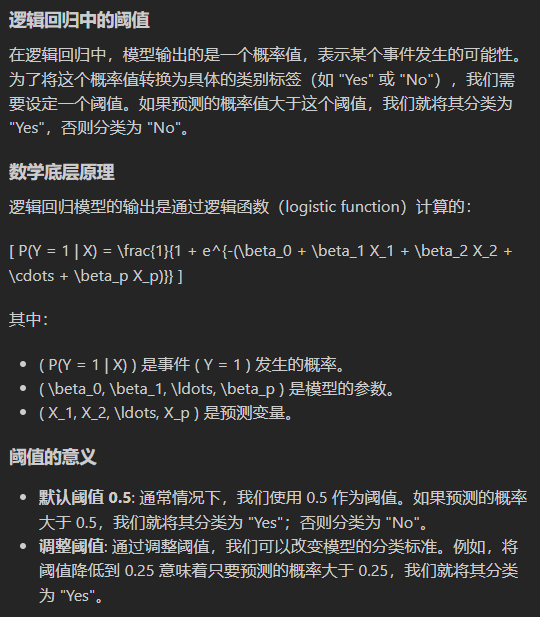

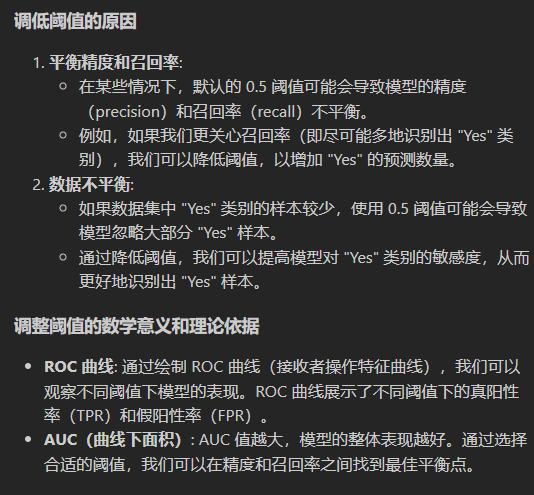

In [ ]:
# 我们可以使用ROC曲线来检验不同阈值下的逻辑回归模型的效果，以找到最佳的阈值




Updating HTML index of packages in '.Library'

Making 'packages.html' ...
 done

Type 'citation("pROC")' for a citation.


Attaching package: ‘pROC’


The following objects are masked from ‘package:stats’:

    cov, smooth, var


Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”
Setting levels: control = No, case = Yes

Setting direction: controls < cases



[1] "AUC: 0.740746411138529"


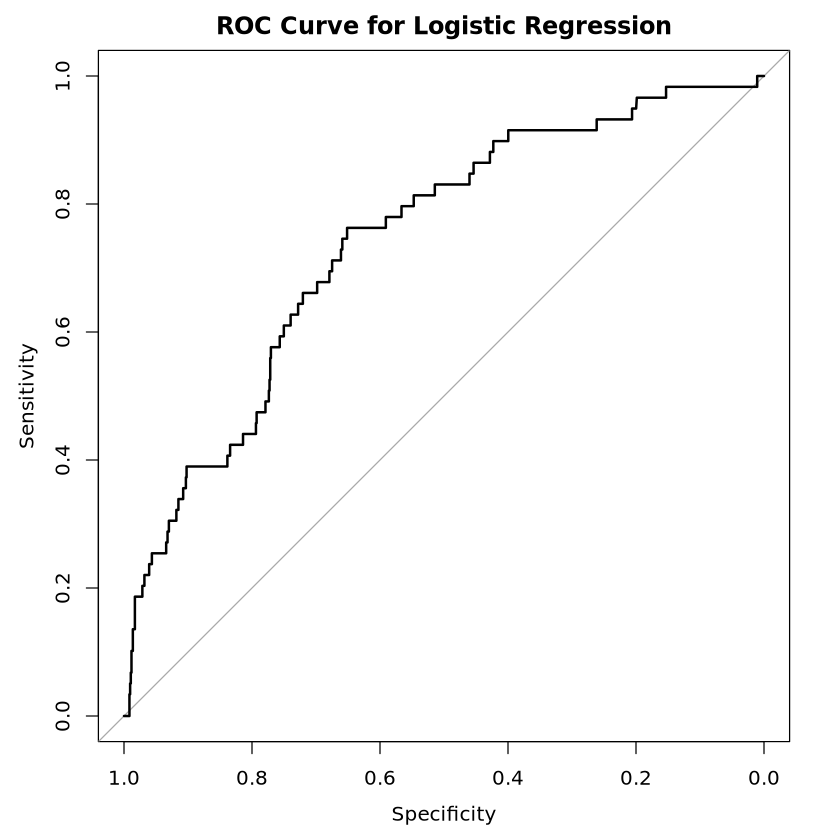

In [68]:
install.packages("pROC")
# 加载必要的包
library(pROC)

# 计算预测概率
glm.fits <- glm(Purchase ~ ., data = Caravan, family = binomial, subset = -test)
glm.probs <- predict(glm.fits, Caravan[test, ], type = "response")

# 绘制 ROC 曲线并计算 AUC 值
roc_curve <- roc(test.Y, glm.probs)
plot(roc_curve, main = "ROC Curve for Logistic Regression")
auc_value <- auc(roc_curve)
print(paste("AUC:", auc_value))

Warning message:
“glm.fit: fitted probabilities numerically 0 or 1 occurred”


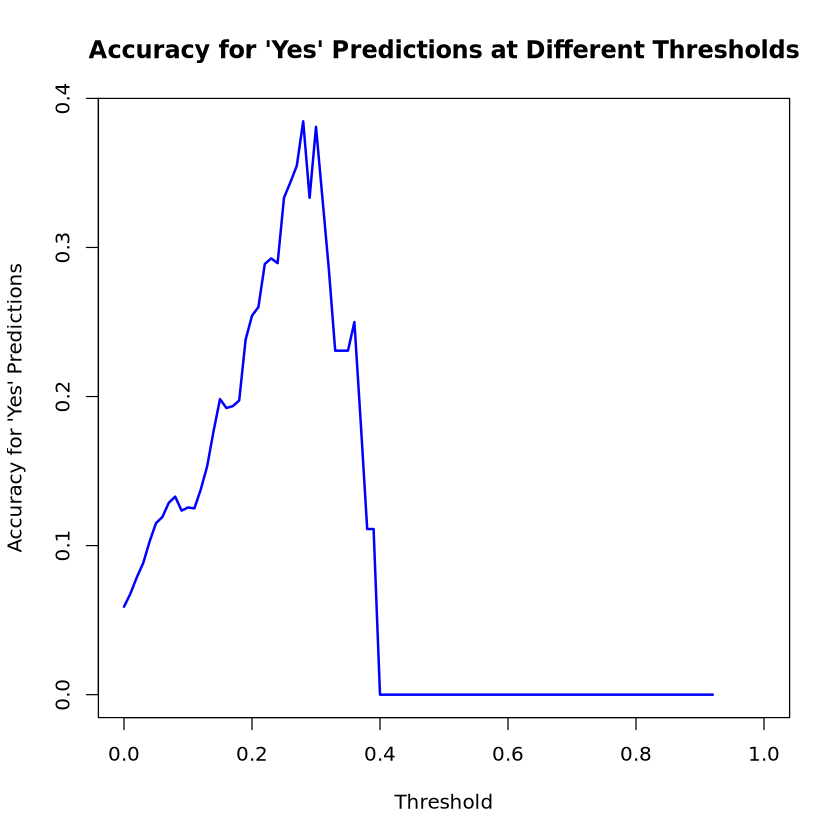

In [69]:
# 或者我们的目的只是为了查看效果，其实不用ROC曲线，只是简单查看模型的准确率等效果罢了

# 拟合逻辑回归模型
glm.fits <- glm(Purchase ~ ., data = Caravan, family = binomial, subset = -test)
glm.probs <- predict(glm.fits, Caravan[test, ], type = "response")

# 初始化变量
thresholds <- seq(0, 1, by = 0.01)
yes_accuracy <- numeric(length(thresholds))

# 计算不同阈值下的预测准确率
for (i in 1:length(thresholds)) {
  threshold <- thresholds[i]
  glm.pred <- ifelse(glm.probs > threshold, "Yes", "No")
  yes_accuracy[i] <- sum(glm.pred == "Yes" & test.Y == "Yes") / sum(glm.pred == "Yes")
}

# 绘制准确率曲线
plot(thresholds, yes_accuracy, type = "l", col = "blue", lwd = 2,
     xlab = "Threshold", ylab = "Accuracy for 'Yes' Predictions",
     main = "Accuracy for 'Yes' Predictions at Different Thresholds")

6，Poisson Regression 泊松回归

最后，我们对Bikeshare数据集建立了泊松回归模型，该数据集测量了华盛顿特区每小时的自行车租赁（骑自行车的人）数量。数据可以在ISLR2库中找到。

In [4]:
attach(Bikeshare)
dim(Bikeshare)

head(Bikeshare)
names(Bikeshare)

The following objects are masked from Bikeshare (pos = 3):

    atemp, bikers, casual, day, holiday, hr, hum, mnth, registered,
    season, temp, weathersit, weekday, windspeed, workingday


The following objects are masked from Bikeshare (pos = 4):

    atemp, bikers, casual, day, holiday, hr, hum, mnth, registered,
    season, temp, weathersit, weekday, windspeed, workingday




[1] 8645   15

,season,mnth,day,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,bikers
,<dbl>,<fct>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,1,Jan,1,0,0,6,0,clear,0.24,0.2879,0.81,0.0000,3,13,16
2,1,Jan,1,1,0,6,0,clear,0.22,0.2727,0.80,0.0000,8,32,40
3,1,Jan,1,2,0,6,0,clear,0.22,0.2727,0.80,0.0000,5,27,32
4,1,Jan,1,3,0,6,0,clear,0.24,0.2879,0.75,0.0000,3,10,13
5,1,Jan,1,4,0,6,0,clear,0.24,0.2879,0.75,0.0000,0,1,1
6,1,Jan,1,5,0,6,0,cloudy/misty,0.24,0.2576,0.75,0.0896,0,1,1


[1] "season"     "mnth"       "day"        "hr"         "holiday"   
 [6] "weekday"    "workingday" "weathersit" "temp"       "atemp"     
[11] "hum"        "windspeed"  "casual"     "registered" "bikers"

我们首先对数据拟合一个最小二乘线性回归模型。

In [5]:
mod.lm <- lm(
bikers ~ mnth + hr + workingday + temp + weathersit,data = Bikeshare
)
summary(mod.lm)


Call:
lm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    data = Bikeshare)

Residuals:
    Min      1Q  Median      3Q     Max 
-299.00  -45.70   -6.23   41.08  425.29 

Coefficients:
                          Estimate Std. Error t value Pr(>|t|)    
(Intercept)                -68.632      5.307 -12.932  < 2e-16 ***
mnthFeb                      6.845      4.287   1.597 0.110398    
mnthMarch                   16.551      4.301   3.848 0.000120 ***
mnthApril                   41.425      4.972   8.331  < 2e-16 ***
mnthMay                     72.557      5.641  12.862  < 2e-16 ***
mnthJune                    67.819      6.544  10.364  < 2e-16 ***
mnthJuly                    45.324      7.081   6.401 1.63e-10 ***
mnthAug                     53.243      6.640   8.019 1.21e-15 ***
mnthSept                    66.678      5.925  11.254  < 2e-16 ***
mnthOct                     75.834      4.950  15.319  < 2e-16 ***
mnthNov                     60.310      4.610  13.083  < 2

由于空间限制，我们截断了summary（mod.lm）的输出。在mod.lm中，hr(0)和mnth(1)的第一个水平被视为基线值，因此没有为它们提供系数估计值：隐式地，它们的系数估计值为零，所有其他水平都是相对于这些基线测量的。例如，2月的系数为6.845意味着，在保持所有其他变量不变的情况下，2月平均比1月多7个骑手。同样，3月份的乘客人数比1月份增加了16.5人。

在4.6.1节中看到的结果使用了一个稍微不同的变量hr和mnth的编码，如下：

In [11]:
contrasts(Bikeshare$hr) = contr.sum(24) 
contrasts(Bikeshare$mnth) = contr.sum(12)

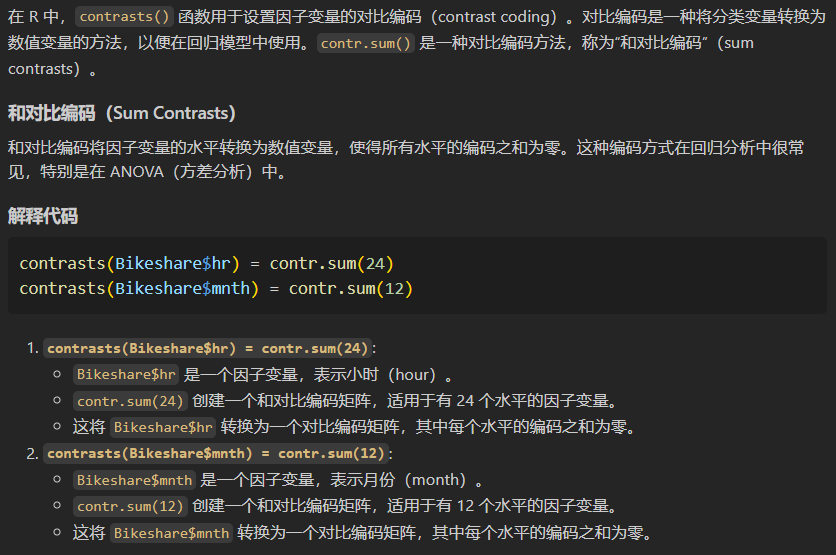

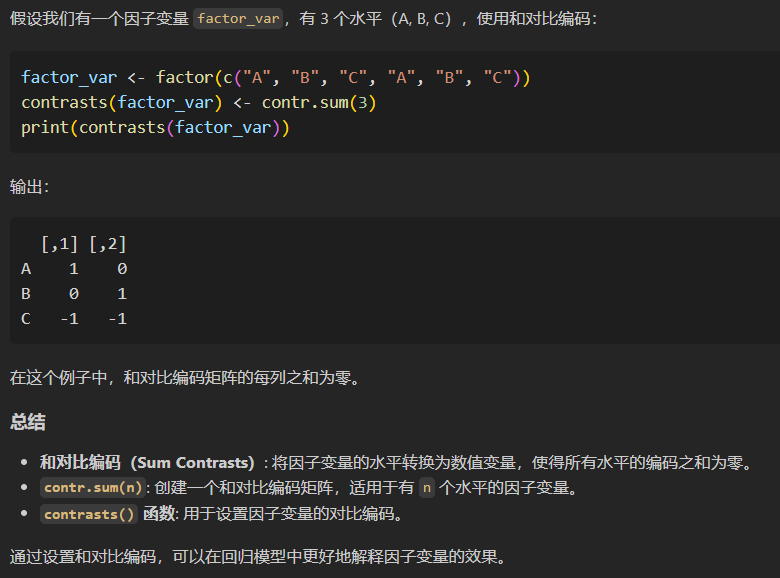

对于每一个编码feature而言，所有水平上的编码值之和为0，也就是每一列之和为0

In [18]:
contrasts(Bikeshare$hr)  
contrasts(Bikeshare$mnth)
print(colSums(contrasts(Bikeshare$hr)))
print(colSums(contrasts(Bikeshare$mnth)))


0,1,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
1,0,1,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
2,0,0,1,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
3,0,0,0,1,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,1,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
5,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
6,0,0,0,0,0,0,1,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
7,0,0,0,0,0,0,0,1,0,0,⋯,0,0,0,0,0,0,0,0,0,0
8,0,0,0,0,0,0,0,0,1,0,⋯,0,0,0,0,0,0,0,0,0,0
9,0,0,0,0,0,0,0,0,0,1,⋯,0,0,0,0,0,0,0,0,0,0
10,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


Jan,1,0,0,0,0,0,0,0,0,0,0
Feb,0,1,0,0,0,0,0,0,0,0,0
March,0,0,1,0,0,0,0,0,0,0,0
April,0,0,0,1,0,0,0,0,0,0,0
May,0,0,0,0,1,0,0,0,0,0,0
June,0,0,0,0,0,1,0,0,0,0,0
July,0,0,0,0,0,0,1,0,0,0,0
Aug,0,0,0,0,0,0,0,1,0,0,0
Sept,0,0,0,0,0,0,0,0,1,0,0
Oct,0,0,0,0,0,0,0,0,0,1,0
Nov,0,0,0,0,0,0,0,0,0,0,1


 [1] 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 [1] 0 0 0 0 0 0 0 0 0 0 0


In [19]:
mod.lm2 <- lm(
bikers ~ mnth + hr + workingday + temp + weathersit,
data = Bikeshare
)
summary(mod.lm2)


Call:
lm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    data = Bikeshare)

Residuals:
    Min      1Q  Median      3Q     Max 
-299.00  -45.70   -6.23   41.08  425.29 

Coefficients:
                           Estimate Std. Error t value Pr(>|t|)    
(Intercept)                 73.5974     5.1322  14.340  < 2e-16 ***
mnth1                      -46.0871     4.0855 -11.281  < 2e-16 ***
mnth2                      -39.2419     3.5391 -11.088  < 2e-16 ***
mnth3                      -29.5357     3.1552  -9.361  < 2e-16 ***
mnth4                       -4.6622     2.7406  -1.701  0.08895 .  
mnth5                       26.4700     2.8508   9.285  < 2e-16 ***
mnth6                       21.7317     3.4651   6.272 3.75e-10 ***
mnth7                       -0.7626     3.9084  -0.195  0.84530    
mnth8                        7.1560     3.5347   2.024  0.04295 *  
mnth9                       20.5912     3.0456   6.761 1.46e-11 ***
mnth10                      29.7472     2.6995 

这两种编码的区别是什么？在mod.lm2中，除了hr和mnth的最后一个水平外，报告了所有的系数估计值。重要的是，在mod.lm2中，mnth最后一层的系数估计值不为零：相反，它等于所有其他层的系数估计值的负总和。类似地，在mod1m2中，最后一个hr水平的系数估计值是所有其他水平的系数估计值之和的负数。这意味着mod.lm2中的hr和mnth的系数总和总是为零，并且可以解释为与平均值水平的差。例如，1月份的系数为- 46.087，表明在保持所有其他变量不变的情况下，1月份的乘客数量通常比年平均少46人。

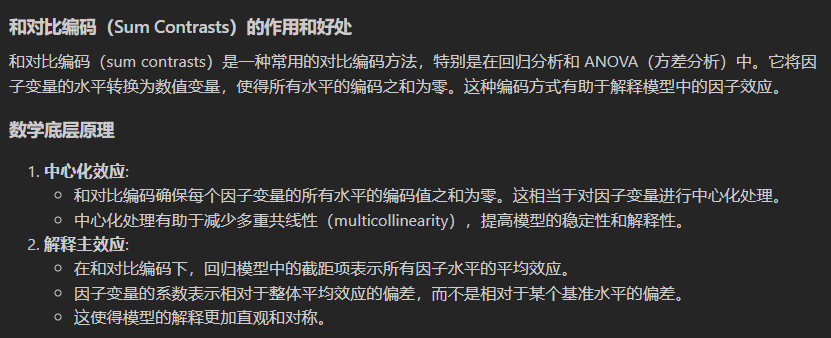

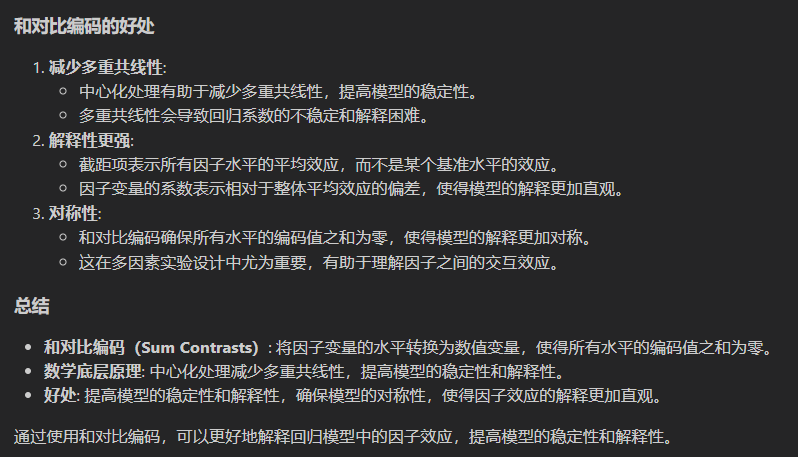

重要的是要认识到，编码的选择实际上并不重要，前提是我们根据所使用的编码正确地解释模型输出。例如，我们发现无论编码如何，线性模型的预测结果都是相同的：

In [20]:
sum((predict(mod.lm) - predict(mod.lm2))^2)

[1] 4.304554e-22

差的平方和是零。使用all.equal（）函数也可以看到这一点：

In [21]:
all.equal(predict(mod.lm), predict(mod.lm2))

[1] TRUE

为了再现图4.13的左边，我们必须首先获得与mnth相关的系数估计值。1月到11月的系数可以直接从mod.lm2对象中获得。12月的系数必须明确地计算为所有其他月份的负和。

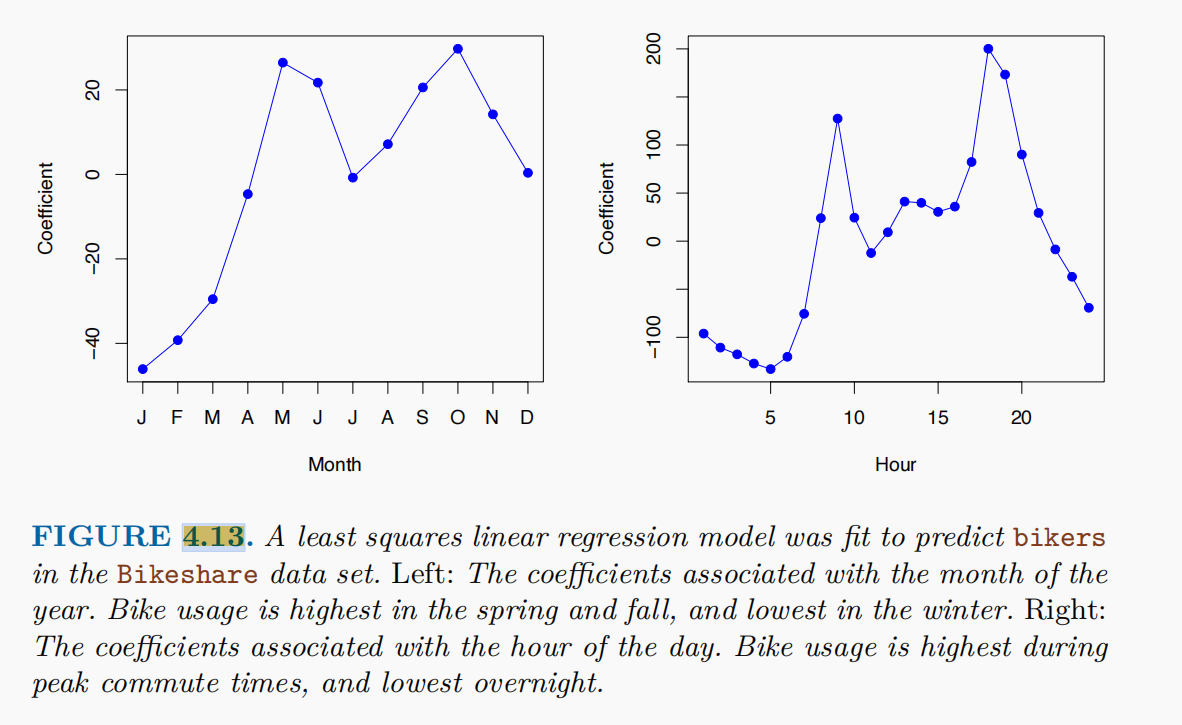

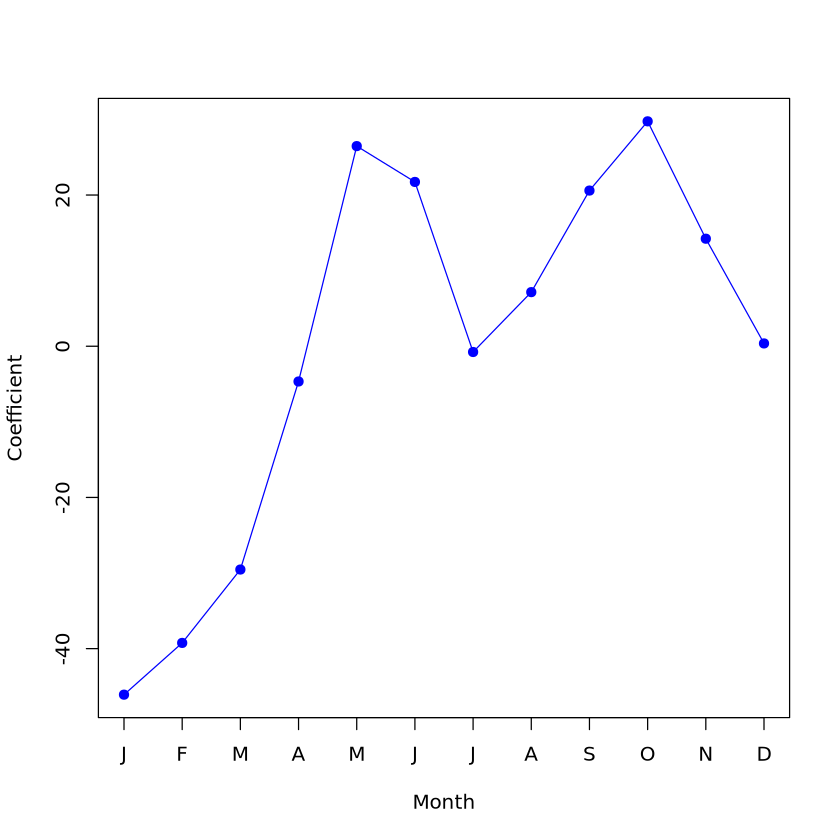

In [ ]:
coef.months <- c(coef(mod.lm2)[2:12],-sum(coef(mod.lm2)[2:12]))

plot(coef.months, xlab = "Month", ylab = "Coefficient",xaxt = "n", col = "blue", pch = 19, type = "o")
axis(side = 1, at = 1:12, labels = c("J", "F", "M", "A","M", "J", "J", "A", "S", "O", "N", "D"))

In [27]:
print(coef(mod.lm2))
print(coef(mod.lm2)[2]) # 从第2个元素开始才是月份的系数，第1个元素是截距
print(coef(mod.lm2)[2:12]) # 1月到11月的系数
print(-sum(coef(mod.lm2)[2:12])) # 12月的系数

              (Intercept)                     mnth1                     mnth2 
               73.5974281               -46.0870904               -39.2418876 
                    mnth3                     mnth4                     mnth5 
              -29.5356525                -4.6621835                26.4699931 
                    mnth6                     mnth7                     mnth8 
               21.7316584                -0.7626304                 7.1559504 
                    mnth9                    mnth10                    mnth11 
               20.5911861                29.7471620                14.2229125 
                      hr1                       hr2                       hr3 
              -96.1420413              -110.7213079              -117.7211804 
                      hr4                       hr5                       hr6 
             -127.2827974              -133.0495462              -120.2775226 
                      hr7                       hr8 

再现图4.13的右边遵循类似的过程。

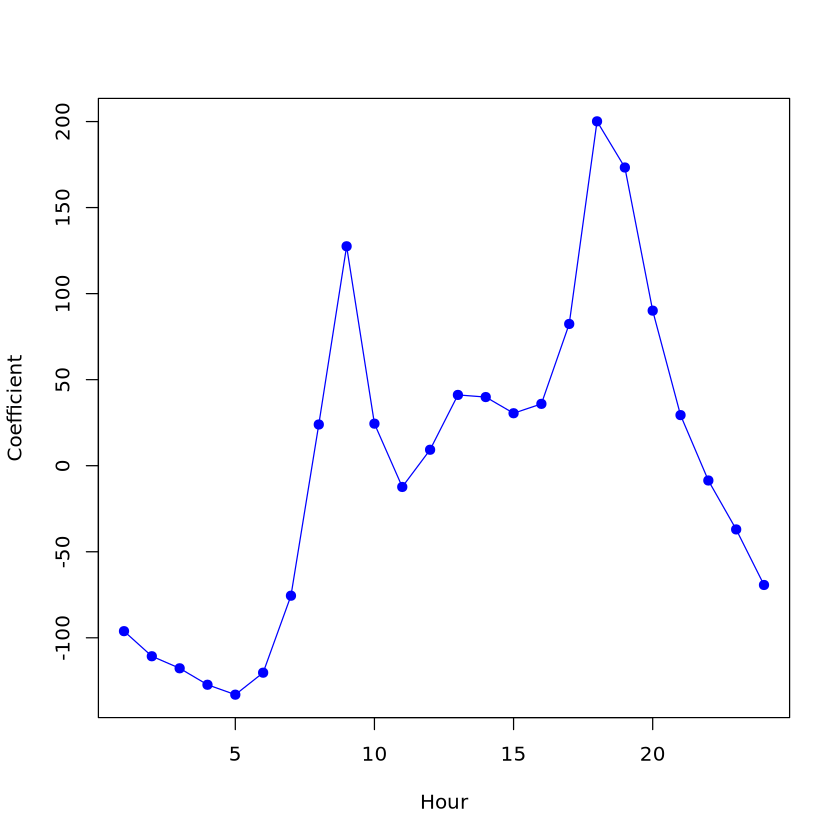

In [32]:
coef.hours <- c(coef(mod.lm2)[13:35],-sum(coef(mod.lm2)[13:35])) # hr1-hr23的系数，hr24的系数
plot(coef.hours, xlab = "Hour", ylab = "Coefficient",col = "blue", pch = 19, type = "o")

现在，我们转而考虑对Bikeshare数据拟合一个泊松回归模型。几乎没有变化，除了我们现在使用函数glm（）和参数family = poisson来指定我们希望适合泊松回归模型：

In [33]:
mod.pois <- glm(
bikers ~ mnth + hr + workingday + temp + weathersit,
data = Bikeshare, family = poisson
)
summary(mod.pois)


Call:
glm(formula = bikers ~ mnth + hr + workingday + temp + weathersit, 
    family = poisson, data = Bikeshare)

Coefficients:
                           Estimate Std. Error  z value Pr(>|z|)    
(Intercept)                4.118245   0.006021  683.964  < 2e-16 ***
mnth1                     -0.670170   0.005907 -113.445  < 2e-16 ***
mnth2                     -0.444124   0.004860  -91.379  < 2e-16 ***
mnth3                     -0.293733   0.004144  -70.886  < 2e-16 ***
mnth4                      0.021523   0.003125    6.888 5.66e-12 ***
mnth5                      0.240471   0.002916   82.462  < 2e-16 ***
mnth6                      0.223235   0.003554   62.818  < 2e-16 ***
mnth7                      0.103617   0.004125   25.121  < 2e-16 ***
mnth8                      0.151171   0.003662   41.281  < 2e-16 ***
mnth9                      0.233493   0.003102   75.281  < 2e-16 ***
mnth10                     0.267573   0.002785   96.091  < 2e-16 ***
mnth11                     0.150264   0.00

我们可以绘制与mnth和hr相关的系数，以便重现图4.15：

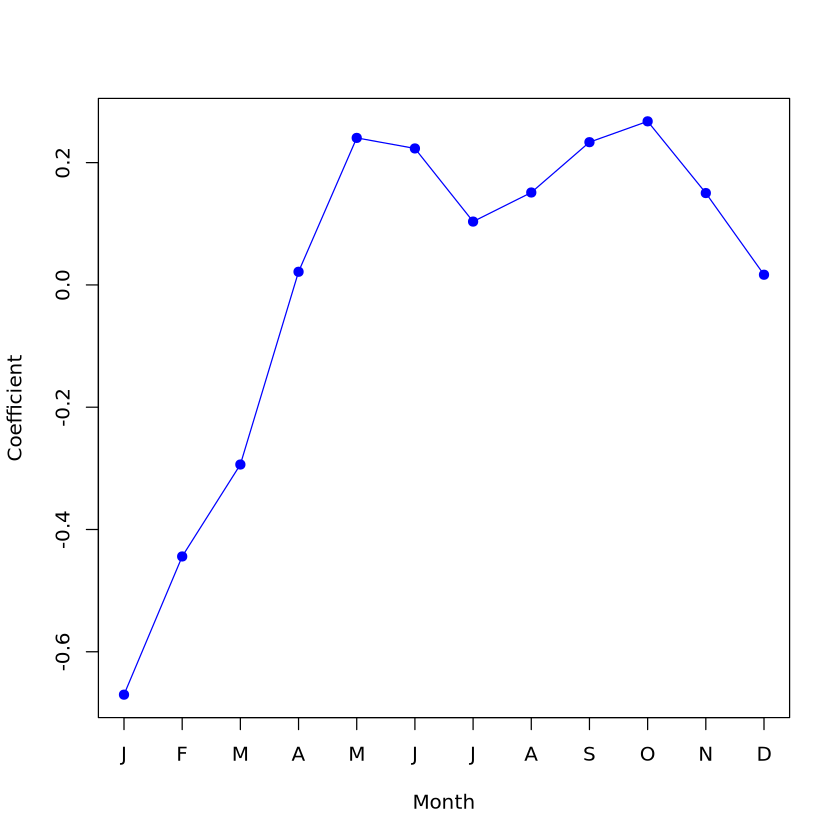

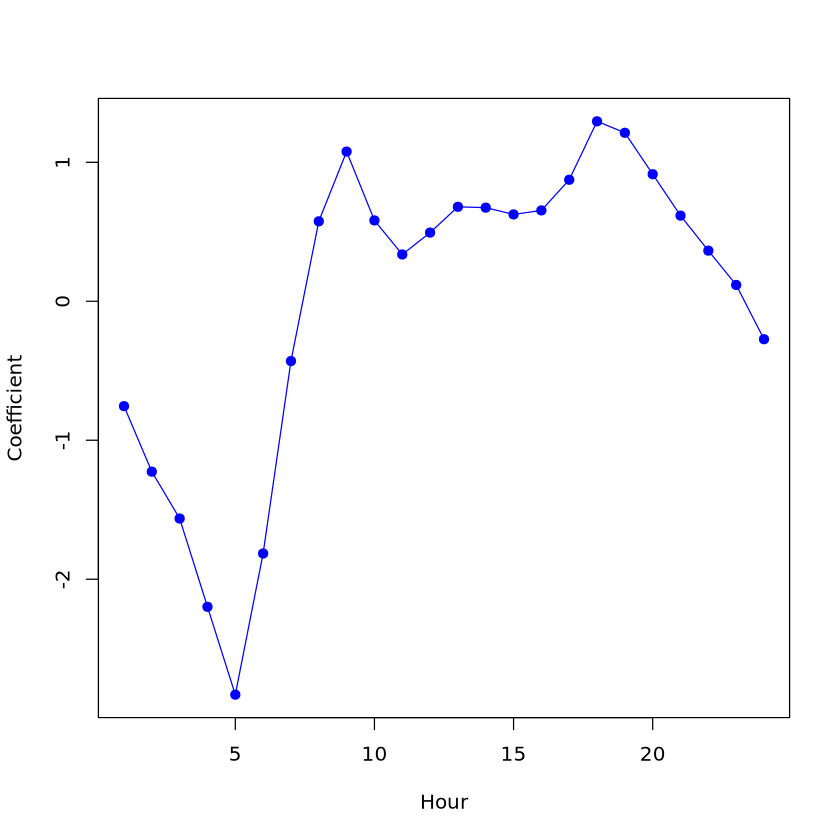

In [34]:
coef.mnth <- c(coef(mod.pois)[2:12],-sum(coef(mod.pois)[2:12]))
plot(coef.mnth, xlab = "Month", ylab = "Coefficient",xaxt = "n", col = "blue", pch = 19, type = "o")
axis(side = 1, at = 1:12, labels = c("J", "F", "M", "A", "M", "J", "J", "A", "S", "O", "N", "D"))

coef.hours <- c(coef(mod.pois)[13:35],-sum(coef(mod.pois)[13:35]))
plot(coef.hours, xlab = "Hour", ylab = "Coefficient",col = "blue", pch = 19, type = "o")

我们可以再次使用predict（）函数从这个泊松回归模型中获得拟合值（预测值）。但是，我们必须使用参数type = "response"来指定我们希望R输出exp(βˆ0 +βˆ1X1+…+βˆpXp)，而不是βˆ0+βˆ1X1+…+βˆpXp，默认输出。

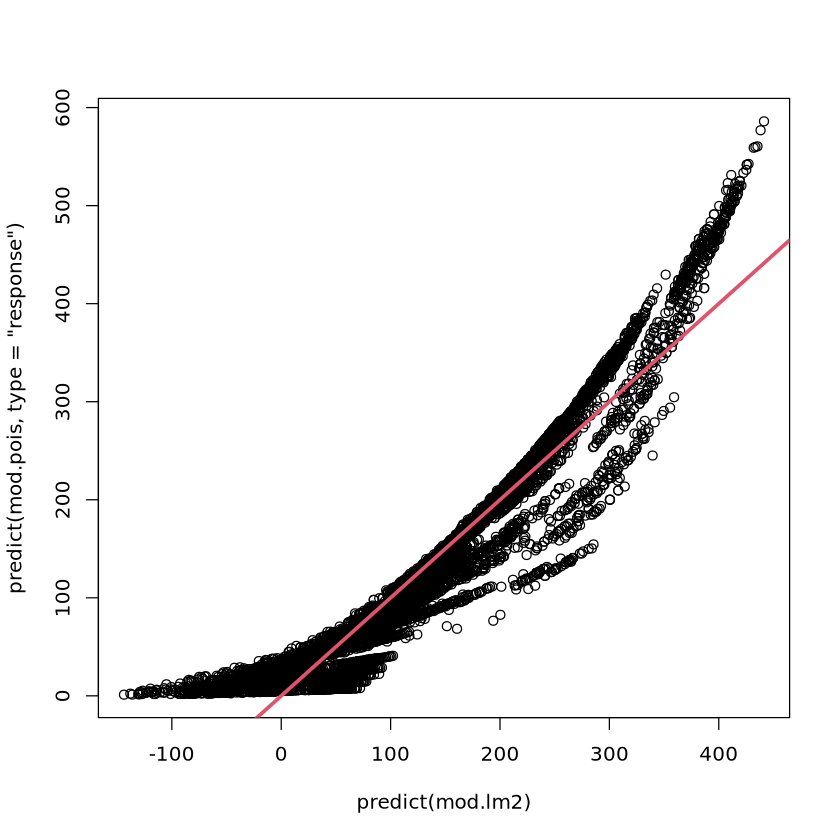

In [36]:
plot(predict(mod.lm2), predict(mod.pois, type = "response"))
abline(0, 1, col = 2, lwd = 3)

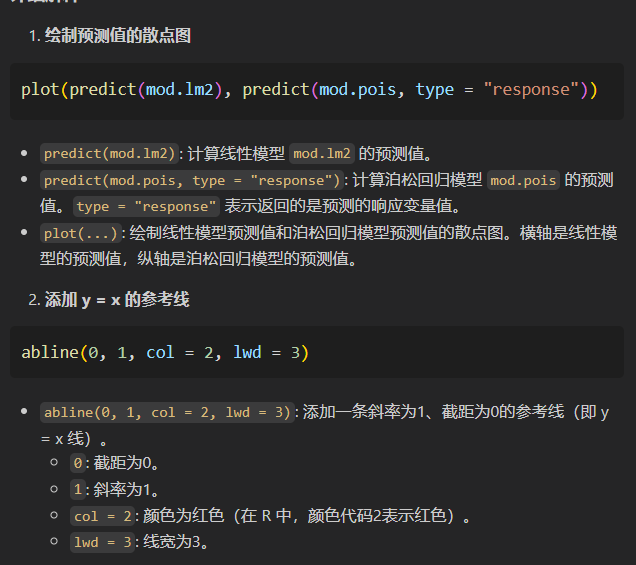

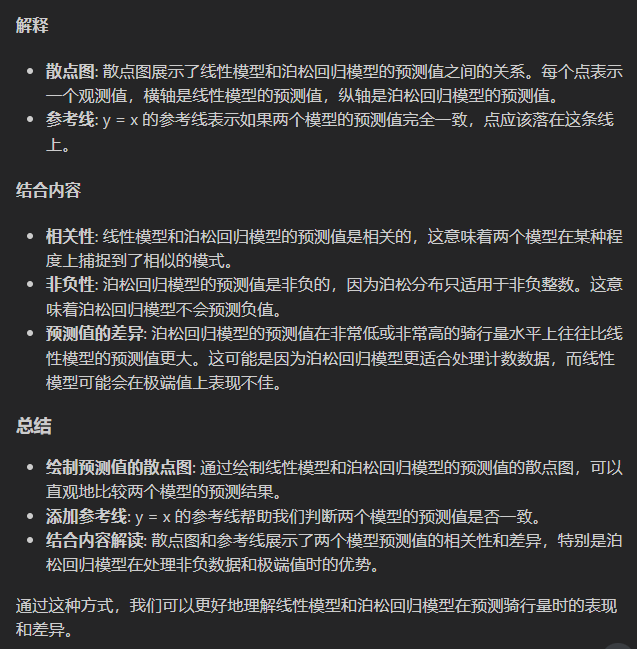

泊松回归模型的预测结果与线性模型的预测结果相关；然而，前者是非负的。因此，对于非常低或非常高的客流量水平，泊松回归的预测往往比线性模型的预测要大。

在本节中，我们使用参数family = poisson的glm（）函数来执行泊松回归。在本实验室的早期，我们使用带有family = binomial的glm（）函数来执行逻辑回归。family参数的其他选择可以用于适合其他类型的glm。例如，family = Gamma是一个Gamma回归模型。

二，练习：Section 4.8 Exercises 3, 5, 12, 13, 15

3，

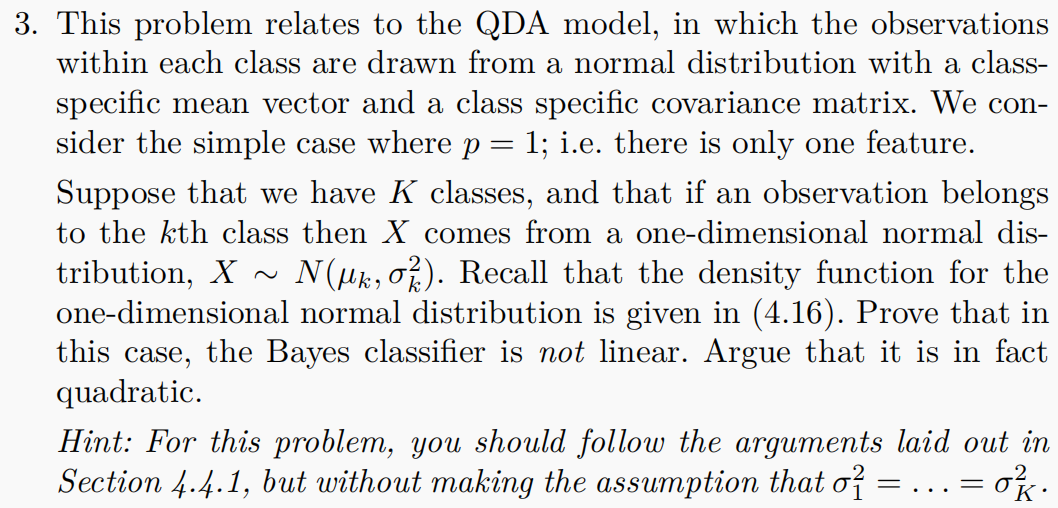

这个问题与QDA模型有关，在QDA模型中，每个类别内的观察值来自一个正态分布，具有类别特定的平均向量和类别特定的协方差矩阵。

我们考虑一个简单的情况，p = 1；也就是说，只有一个特征。假设我们有K个类，如果一个观测值属于第K个类，那么X来自一个一维正态分布，X ~ N（µK, σ k2）。回想一下一维正态分布的密度函数在（4.16）中给出。证明在这种情况下，贝叶斯分类器不是线性的。认为它实际上是二次的。提示：对于这个问题，您应该遵循第4.4.1节给出的参数，但不要假设σ 12 =…σk 2。

首先依据贝叶斯分类器的定义，我们有

$$
p_k(x) = \frac{\pi_k\frac{1}{\sqrt{2\pi\sigma_k}} \exp(-\frac{1}{2\sigma_k^2}(x - \mu_k)^2)}
              {\sum_{l=1}^k \pi_l\frac{1}{\sqrt{2\pi\sigma_l}} \exp(-\frac{1}{2\sigma_l^2}(x - \mu_l)^2)}
$$

注意：以后每次markdown格式的回答，格式" \( X \) " 部分都改为 “$ X $”，单个$是一行内，双$$是分行《—————以md格式查看该注意事项！！！！

### 问题背景
这段内容是关于QDA（Quadratic Discriminant Analysis，二次判别分析）模型的。在QDA模型中，每个类别的观测值都被假设为来自一个具有类别特定均值向量和类别特定协方差矩阵的正态分布。这里考虑的是一个简化的情况，即只有1个特征$ p = 1 $ 

### 具体问题
假设我们有 $ K $ 个类别，如果一个观测值属于第 $ k $个类别，那么 $ X $ 服从一维正态分布 $ X \sim N(\mu_k, \sigma^2) $。我们需要证明在这种情况下，贝叶斯分类器不是线性的，而是二次的。

### 解题思路
为了证明贝叶斯分类器在这种情况下不是线性的，而是二次的，我们需要从贝叶斯分类器的定义出发，逐步推导出其决策边界的形式。

### 贝叶斯分类器的定义
贝叶斯分类器的目标是将观测值分配到后验概率最大的类别。对于一个观测值 $ x $，其属于第$ k $ 个类别的后验概率为：
$$
p_k(x) = \frac{\pi_k f_k(x)}{\sum_{l=1}^K \pi_l f_l(x)}
$$
其中，$ \pi_k $ 是第 $ k $ 个类别的先验概率，$ f_k(x) $ 是 $ x $ 在第 $ k $ 个类别下的概率密度函数。

### 一维正态分布的概率密度函数
对于一维正态分布 $ X \sim N(\mu_k, \sigma_k^2) $，其概率密度函数为：
$
f_k(x) = \frac{1}{\sqrt{2\pi\sigma_k^2}} \exp\left(-\frac{(x - \mu_k)^2}{2\sigma_k^2}\right)
$

### 代入贝叶斯分类器
将 $ f_k(x) $ 代入贝叶斯分类器的公式中，得到：
$$
p_k(x) = \frac{\pi_k \frac{1}{\sqrt{2\pi\sigma_k^2}} \exp\left(-\frac{(x - \mu_k)^2}{2\sigma_k^2}\right)}{\sum_{l=1}^K \pi_l \frac{1}{\sqrt{2\pi\sigma_l^2}} \exp\left(-\frac{(x - \mu_l)^2}{2\sigma_l^2}\right)}
$$

### 取对数
为了简化计算，我们取对数：
$$
\log(p_k(x)) = \log(\pi_k) + \log\left(\frac{1}{\sqrt{2\pi\sigma_k^2}}\right) - \frac{(x - \mu_k)^2}{2\sigma_k^2} - \log\left(\sum_{l=1}^K \pi_l \frac{1}{\sqrt{2\pi\sigma_l^2}} \exp\left(-\frac{(x - \mu_l)^2}{2\sigma_l^2}\right)\right)
$$

### 忽略不随 $ k $ 变化的项
在最大化 $ \log(p_k(x)) $ 时，最后一项不随 $ k $ 变化，可以忽略。因此，我们只需要最大化：
$$
f_k(x) = \log(\pi_k) + \log\left(\frac{1}{\sqrt{2\pi\sigma_k^2}}\right) - \frac{(x - \mu_k)^2}{2\sigma_k^2}
$$

### 展开平方项
展开平方项：
$$
f_k(x) = \log(\pi_k) + \log\left(\frac{1}{\sqrt{2\pi\sigma_k^2}}\right) - \frac{x^2}{2\sigma_k^2} + \frac{x\mu_k}{\sigma_k^2} - \frac{\mu_k^2}{2\sigma_k^2}
$$

### 二次项的存在
注意到，$ \frac{x^2}{2\sigma_k^2} $ 这一项是关于 $ x $ 的二次项，并且它依赖于 $ k $。因此，$ f_k(x) $ 是关于 $ x $ 的二次函数。

### 结论
由于 $ f_k(x) $ 是关于 $ x $ 的二次函数，因此贝叶斯分类器在这种情况下是二次的，而不是线性的。

通过上述推导，证明了在QDA模型中，当每个类别的观测值来自具有不同方差的一维正态分布时，贝叶斯分类器是二次的，而不是线性的。

然后对于前面推导过程中的分母项部分，我们在推导细节具体每个类别的概率的时候，不考虑或者忽略分母项部分的原因：

分母项在贝叶斯分类器的决策过程中确实不会影响最大化结果，但这并不意味着它对每个类别是固定的，而是因为它在整个决策过程中是**常数项**，不会改变各个类别之间的相对大小关系。

### 具体解释

在贝叶斯分类器中，我们希望最大化后验概率 $ p_k(x) $，即：
$$
p_k(x) = \frac{\pi_k f_k(x)}{\sum_{l=1}^K \pi_l f_l(x)}
$$
其中：
- $ \pi_k $ 是第 $ k $ 个类别的先验概率。
- $ f_k(x) $ 是 $ x $ 在第 $ k $ 个类别下的概率密度函数。
- 分母 $ \sum_{l=1}^K \pi_l f_l(x) $ 是所有类别的先验概率与概率密度函数的加权和。

### 分母的作用
分母 $ \sum_{l=1}^K \pi_l f_l(x) $ 的作用是**归一化**，确保所有类别的后验概率之和为1。然而，在决策过程中，我们并不需要计算具体的后验概率值，而是需要找到使后验概率最大的类别 $ k $。

### 为什么分母不影响最大化
在最大化 $ p_k(x) $ 时，我们实际上是在比较不同类别 $ k $ 的分子 $ \pi_k f_k(x) $。分母对于所有类别是相同的，因此它不会改变分子之间的相对大小关系。换句话说，最大化 $ p_k(x) $ 等价于最大化分子 $ \pi_k f_k(x) $。

### 分母的具体值
分母的具体值是：
$$
\sum_{l=1}^K \pi_l f_l(x) = \sum_{l=1}^K \pi_l \cdot \frac{1}{\sqrt{2\pi\sigma_l^2}} \exp\left(-\frac{(x - \mu_l)^2}{2\sigma_l^2}\right)
$$
这个值取决于输入 $ x $，并且会随着 $ x $ 的变化而变化。但它对所有类别是相同的，因此在最大化过程中可以忽略。

### 总结
- 分母项 $ \sum_{l=1}^K \pi_l f_l(x) $ 是一个归一化因子，确保后验概率之和为1。
- 在最大化后验概率 $ p_k(x) $ 时，分母对所有类别是相同的，因此不会影响最大化结果。
- 分母的具体值取决于输入 $ x $，但对所有类别是相同的，因此在决策过程中可以忽略。

5，

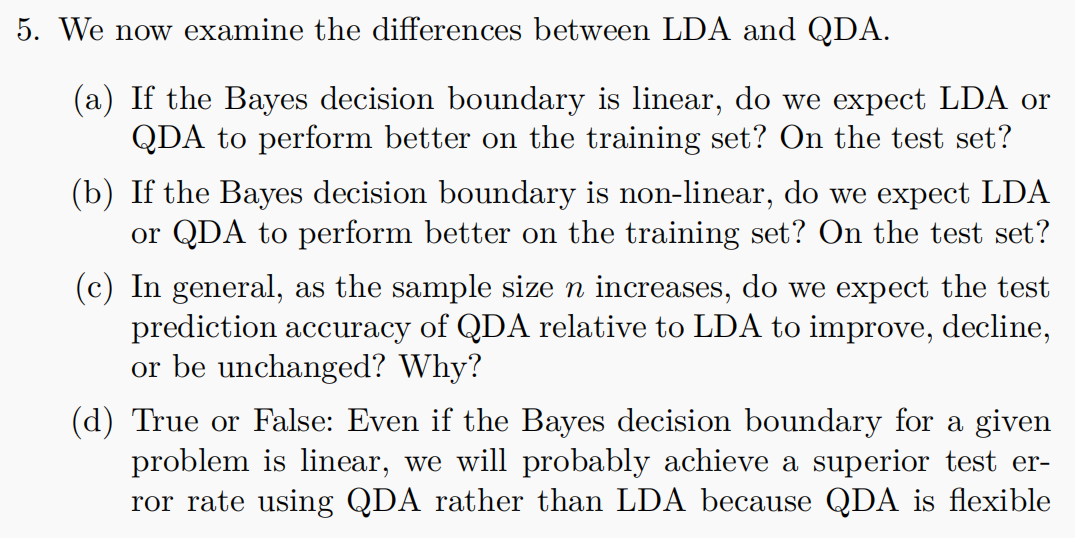

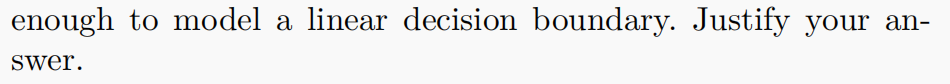

a

训练集：QDA由于模型更灵活，能够更好地拟合训练数据中的细节和噪声，因此在训练集上通常表现更好。

测试集：LDA假设数据服从正态分布且各组的协方差矩阵相等，模型相对简单，更不容易过拟合。在测试集上，LDA通常表现更好，因为它对训练数据的过度拟合较少，能够更好地泛化到新的数据。

b

训练集：QDA由于其模型的灵活性，能够更好地拟合非线性边界，因此在训练集上表现更好。

测试集：理论上，QDA的额外灵活性可能会转化为测试集上的更好拟合。然而，这取决于模型是否能够正确地捕捉到数据中的非线性结构，而不是仅仅拟合训练数据中的噪声。

c

随着样本量的增加，QDA相对于LDA的测试预测准确性通常会提高。这是因为更多的数据可以帮助QDA更好地估计模型参数，从而更准确地捕捉数据中的复杂结构。然而，这也取决于数据中是否存在足够的非线性结构来支持QDA的复杂性。如果数据实际上接近线性可分，那么即使样本量增加，QDA相对于LDA的优势也可能不会显著。

d

判断：错误。

理由：尽管QDA足够灵活可以模拟线性决策边界，但它也可能过度拟合训练数据中的噪声，导致在测试集上的表现更差。相比之下，LDA由于其模型的简单性，更不容易过拟合，因此在测试集上通常表现更好。

12，

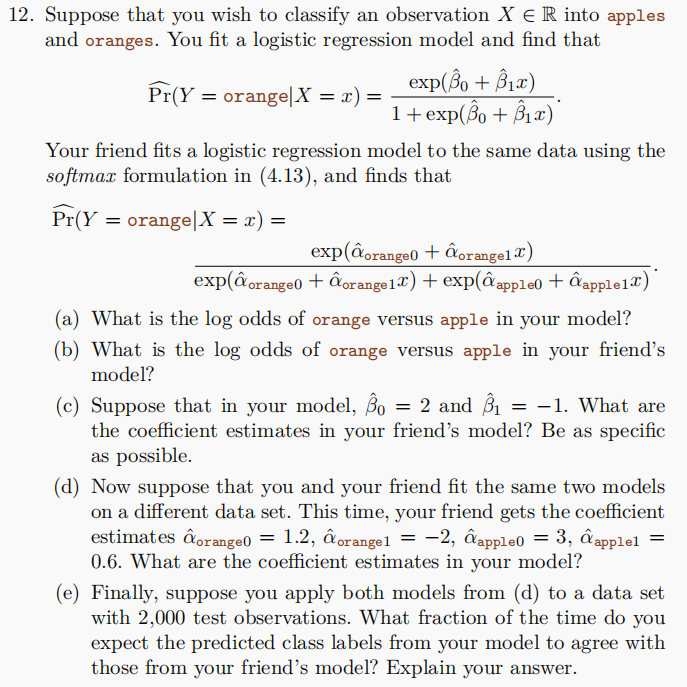

### 问题背景
假设我们有一个观测值 $ X \in \mathbb{R} $，我们希望将其分类为“苹果”或“橙子”。我们使用逻辑回归模型和softmax模型来解决这个问题。

### 问题及解答

#### a. 你的模型中“橙子”相对于“苹果”的对数几率是多少？
在逻辑回归模型中，预测“橙子”的概率为：

$$
\hat{Pr}(Y=\text{orange}|X=x) = \frac{\exp(\hat\beta_0 + \hat\beta_1x)}{1 + \exp(\hat\beta_0 + \hat\beta_1x)}
$$

预测“苹果”的概率为：

$$
\hat{Pr}(Y=\text{apple}|X=x) = 1 - \hat{Pr}(Y=\text{orange}|X=x) = \frac{1}{1 + \exp(\hat\beta_0 + \hat\beta_1x)}
$$

“橙子”相对于“苹果”的对数几率（log odds）是：

$$
\log\left(\frac{\hat{Pr}(Y=\text{orange}|X=x)}{\hat{Pr}(Y=\text{apple}|X=x)}\right) = \log\left(\frac{\frac{\exp(\hat\beta_0 + \hat\beta_1x)}{1 + \exp(\hat\beta_0 + \hat\beta_1x)}}{\frac{1}{1 + \exp(\hat\beta_0 + \hat\beta_1x)}}\right) = \log(\exp(\hat\beta_0 + \hat\beta_1x)) = \hat\beta_0 + \hat\beta_1x
$$

#### b. 你朋友的模型中“橙子”相对于“苹果”的对数几率是多少？
在softmax模型中，预测“橙子”的概率为：

$$
\hat{Pr}(Y=\text{orange}|X=x) = \frac{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x)}{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x) + \exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}
$$

预测“苹果”的概率为：

$$
\hat{Pr}(Y=\text{apple}|X=x) = \frac{\exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x) + \exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}
$$

“橙子”相对于“苹果”的对数几率（log odds）是：

$$
\log\left(\frac{\hat{Pr}(Y=\text{orange}|X=x)}{\hat{Pr}(Y=\text{apple}|X=x)}\right) = \log\left(\frac{\frac{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x)}{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x) + \exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}}{\frac{\exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x) + \exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}}\right) = \log\left(\frac{\exp(\hat\alpha_{\text{orange}0} + \hat\alpha_{\text{orange}1}x)}{\exp(\hat\alpha_{\text{apple}0} + \hat\alpha_{\text{apple}1}x)}\right) = (\hat\alpha_{\text{orange}0} - \hat\alpha_{\text{apple}0}) + (\hat\alpha_{\text{orange}1} - \hat\alpha_{\text{apple}1})x
$$

#### c. 假设在你的模型中，$ \hat\beta_0 = 2 $ 和 $ \hat\beta_1 = -1 $。那么你朋友模型中的系数估计值是多少？尽可能具体。
在我的模型中，对数几率为 $ \hat\beta_0 + \hat\beta_1x = 2 - x $。在我朋友的模型中，对数几率为 $ \hat\alpha_{\text{orange}0} - \hat\alpha_{\text{apple}0}) + (\hat\alpha_{\text{orange}1} - \hat\alpha_{\text{apple}1})x $。因此，我们可以得出：

$$
\hat\alpha_{\text{orange}0} - \hat\alpha_{\text{apple}0} = 2 \quad \text{和} \quad \hat\alpha_{\text{orange}1} - \hat\alpha_{\text{apple}1} = -1
$$

然而，我们无法得知每个参数的具体值，因为它们可以有无限多种组合满足上述条件。

#### d. 现在假设你和你的朋友在另一个数据集上拟合了这两个模型。这次，你朋友得到的系数估计值是 $ \hat\alpha_{\text{orange}0} = 1.2 $，$ \hat\alpha_{\text{orange}1} = -2 $，$ \hat\alpha_{\text{apple}0} = 3 $，$ \hat\alpha_{\text{apple}1} = 0.6 $。那么你模型中的系数估计值是多少？
在我朋友的模型中，对数几率为 $ (\hat\alpha_{\text{orange}0} - \hat\alpha_{\text{apple}0}) + (\hat\alpha_{\text{orange}1} - \hat\alpha_{\text{apple}1})x = (1.2 - 3) + (-2 - 0.6)x = -1.8 - 2.6x $。因此，在我的模型中，系数估计值为：

$$
\hat\beta_0 = -1.8 \quad \text{和} \quad \hat\beta_1 = -2.6
$$

#### e. 最后，假设你将（d）中的两个模型应用于一个包含2000个测试观测值的数据集。你预计你的模型预测的类别标签与你朋友模型预测的类别标签一致的比例是多少？解释你的答案。
这两个模型虽然参数化方式不同，但本质上是相同的，因此它们应该完全一致。因此，预计我的模型预测的类别标签与我朋友模型预测的类别标签一致的比例是100%。

然后上面的推导中我们实际上一直在使用log odds的形式来推导不同模型之间的系数估计值，原因如下：

在二分类问题中，逻辑回归模型和softmax模型虽然形式不同，但它们在本质上是等价的。这是因为它们都试图估计同一个量：对数几率（log odds）。对数几率是事件发生概率与不发生概率的比值的对数，即：

$$
\text{log odds} = \log\left(\frac{P(Y=1)}{P(Y=0)}\right)
$$

在逻辑回归模型中，对数几率被建模为：

$$
\log\left(\frac{P(Y=1|X=x)}{P(Y=0|X=x)}\right) = \beta_0 + \beta_1 x
$$

在softmax模型中，对数几率被建模为：

$$
\log\left(\frac{P(Y=1|X=x)}{P(Y=0|X=x)}\right) = (\alpha_{10} - \alpha_{00}) + (\alpha_{11} - \alpha_{01})x
$$

由于这两个模型都是为了估计同一个量（对数几率），因此它们的对数几率表达式必须相等。这就是为什么在不同模型之间，对数几率是不变的。

在实际应用中，我们可以通过将一个模型的系数转换为另一个模型的系数来实现模型之间的转换。例如，如果我们知道逻辑回归模型的系数 $\beta_0 $ 和 $\beta_1$，那么我们可以通过以下方式计算softmax模型的系数：

$$
\alpha_{10} - \alpha_{00} = \beta_0
$$
$$
\alpha_{11} - \alpha_{01} = \beta_1
$$

同样，如果我们知道softmax模型的系数 $\alpha_{10}$，$\alpha_{11}$，$\alpha_{00}$，和 $\alpha_{01}$，那么我们可以通过以下方式计算逻辑回归模型的系数：

$$
\beta_0 = \alpha_{10} - \alpha_{00}
$$
$$
\beta_1 = \alpha_{11} - \alpha_{01}
$$

这种转换是可能的，因为两个模型都是为了估计同一个量（对数几率），因此它们的对数几率表达式必须相等。这就是为什么在不同模型之间，对数几率是不变的，以及为什么我们可以利用对数几率不变来计算这些系数估计值。

13，

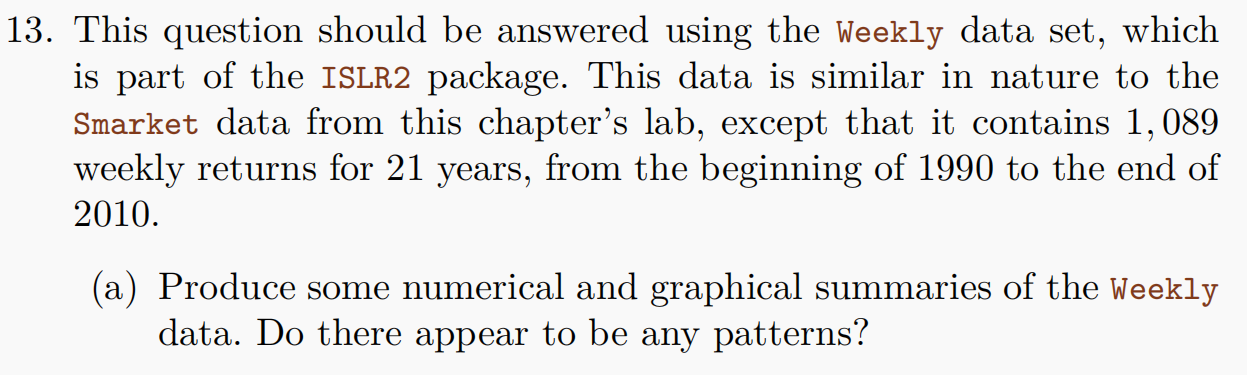
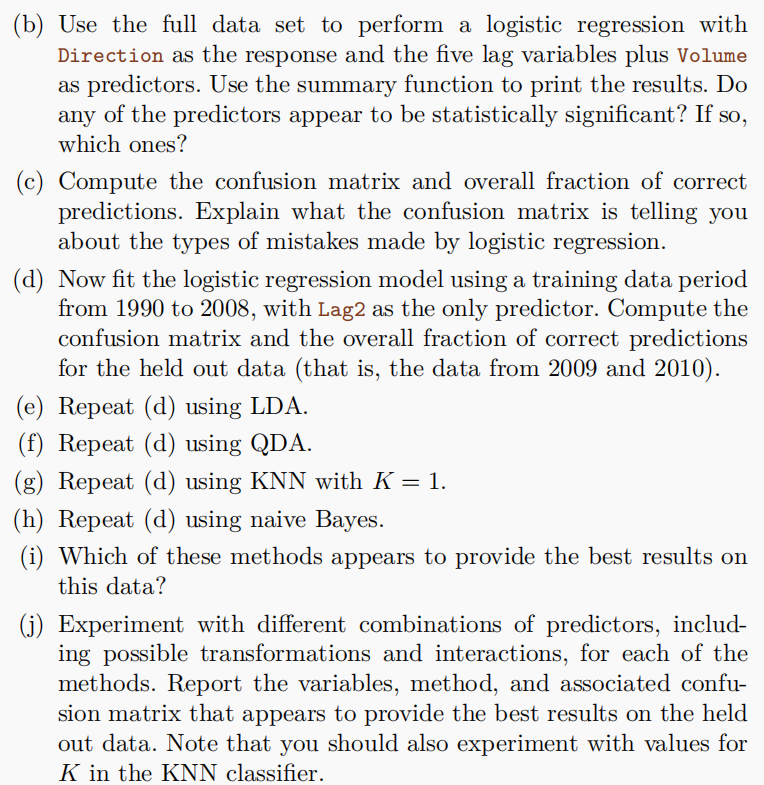

naiveBayes()朴素贝叶斯函数在e1071库中

lda()线性判别分析、qda()二次判别分析函数在MASS库中

In [9]:
# a

library(ISLR2)
library(MASS) # 带有lda、qda函数
library(class) # 带有knn函数
library(e1071) # 带有naiveBayes函数
library(tidyverse)
library(corrplot) 


attach(Weekly)
dim(Weekly)
head(Weekly)
names(Weekly)
summary(Weekly)


Attaching package: ‘MASS’


The following object is masked from ‘package:ISLR2’:

    Boston




── Attaching core tidyverse packages ──────────────────────── tidyverse 2.0.0 ──
✔ dplyr     1.1.4     ✔ readr     2.1.5
✔ forcats   1.0.0     ✔ stringr   1.5.1
✔ ggplot2   3.5.1     ✔ tibble    3.2.1
✔ lubridate 1.9.4     ✔ tidyr     1.3.1
✔ purrr     1.0.2     
── Conflicts ────────────────────────────────────────── tidyverse_conflicts() ──
✖ dplyr::filter() masks stats::filter()
✖ dplyr::lag()    masks stats::lag()
✖ dplyr::select() masks MASS::select()
ℹ Use the conflicted package (<http://conflicted.r-lib.org/>) to force all conflicts to become errors
corrplot 0.95 loaded

The following objects are masked from Weekly (pos = 17):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year


The following objects are masked from Weekly (pos = 18):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year




[1] 1089    9

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today,Direction
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,1990,0.816,1.572,-3.936,-0.229,-3.484,0.1549760,-0.270,Down
2,1990,-0.270,0.816,1.572,-3.936,-0.229,0.1485740,-2.576,Down
3,1990,-2.576,-0.270,0.816,1.572,-3.936,0.1598375,3.514,Up
4,1990,3.514,-2.576,-0.270,0.816,1.572,0.1616300,0.712,Up
5,1990,0.712,3.514,-2.576,-0.270,0.816,0.1537280,1.178,Up
6,1990,1.178,0.712,3.514,-2.576,-0.270,0.1544440,-1.372,Down


[1] "Year"      "Lag1"      "Lag2"      "Lag3"      "Lag4"      "Lag5"     
[7] "Volume"    "Today"     "Direction"

      Year           Lag1               Lag2               Lag3         
 Min.   :1990   Min.   :-18.1950   Min.   :-18.1950   Min.   :-18.1950  
 1st Qu.:1995   1st Qu.: -1.1540   1st Qu.: -1.1540   1st Qu.: -1.1580  
 Median :2000   Median :  0.2410   Median :  0.2410   Median :  0.2410  
 Mean   :2000   Mean   :  0.1506   Mean   :  0.1511   Mean   :  0.1472  
 3rd Qu.:2005   3rd Qu.:  1.4050   3rd Qu.:  1.4090   3rd Qu.:  1.4090  
 Max.   :2010   Max.   : 12.0260   Max.   : 12.0260   Max.   : 12.0260  
      Lag4               Lag5              Volume            Today         
 Min.   :-18.1950   Min.   :-18.1950   Min.   :0.08747   Min.   :-18.1950  
 1st Qu.: -1.1580   1st Qu.: -1.1660   1st Qu.:0.33202   1st Qu.: -1.1540  
 Median :  0.2380   Median :  0.2340   Median :1.00268   Median :  0.2410  
 Mean   :  0.1458   Mean   :  0.1399   Mean   :1.57462   Mean   :  0.1499  
 3rd Qu.:  1.4090   3rd Qu.:  1.4050   3rd Qu.:2.05373   3rd Qu.:  1.4050  
 Max.   : 12.0260   Max.   : 12.0

In [10]:
?corrplot

corrplot               package:corrplot                R Documentation

_A _v_i_s_u_a_l_i_z_a_t_i_o_n _o_f _a _c_o_r_r_e_l_a_t_i_o_n _m_a_t_r_i_x.

_D_e_s_c_r_i_p_t_i_o_n:

     A graphical display of a correlation matrix, confidence interval.
     The details are paid great attention to. It can also visualize a
     general matrix by setting ‘is.corr = FALSE’.

_U_s_a_g_e:

     corrplot(
       corr,
       method = c("circle", "square", "ellipse", "number", "shade", "color", "pie"),
       type = c("full", "lower", "upper"),
       col = NULL,
       col.lim = NULL,
       is.corr = TRUE,
       bg = "white",
       title = "",
       add = FALSE,
       diag = TRUE,
       outline = FALSE,
       mar = c(0, 0, 0, 0),
       addgrid.col = NULL,
       addCoef.col = NULL,
       addCoefasPercent = FALSE,
       order = c("original", "AOE", "FPC", "hclust", "alphabet"),
       hclust.method = c("complete", "ward", "ward.D", "ward.D2", 

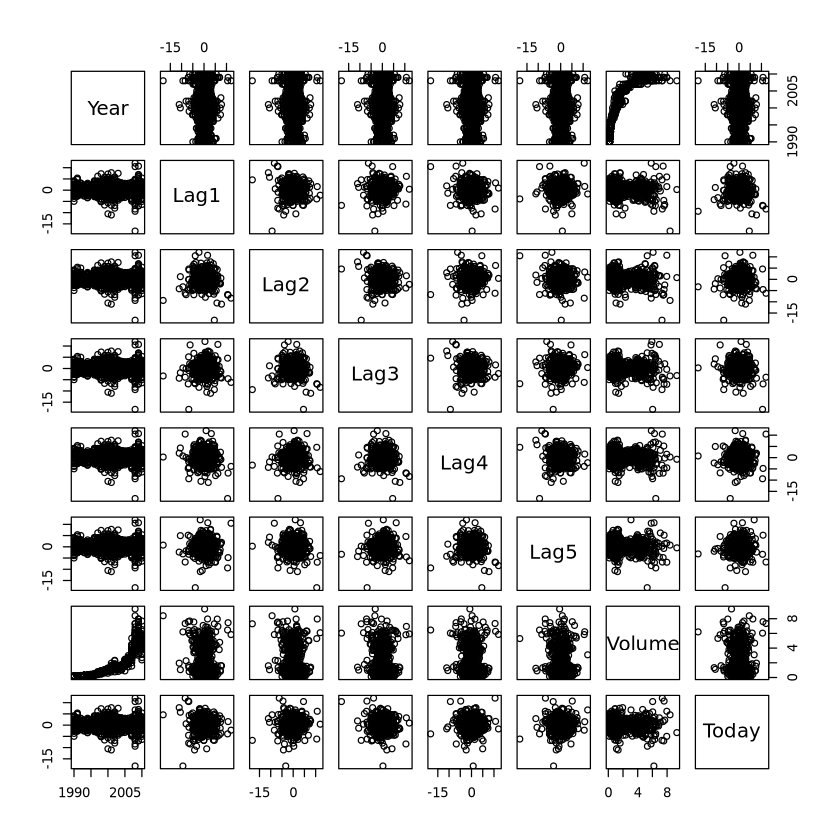

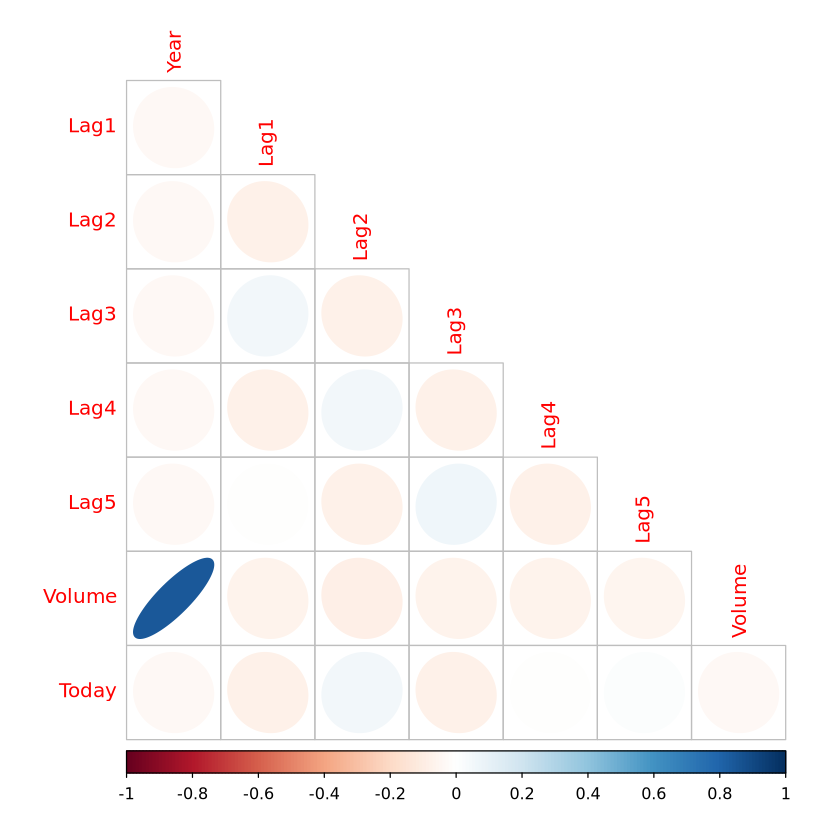

In [ ]:
pairs(Weekly[,-9])
corrplot(cor(Weekly[, -9]), type = "lower", diag = FALSE, method = "ellipse")

# volume成交量与year年份呈强正相关。其他相关系数较低，但Lag1与Lag2呈负相关，与Lag3呈正相关。

In [23]:
cor(Weekly[, -9])

,Year,Lag1,Lag2,Lag3,Lag4,Lag5,Volume,Today
Year,1.00000000,-0.032289274,-0.03339001,-0.03000649,-0.031127923,-0.030519101,0.84194162,-0.032459894
Lag1,-0.03228927,1.000000000,-0.07485305,0.05863568,-0.071273876,-0.008183096,-0.06495131,-0.075031842
Lag2,-0.03339001,-0.074853051,1.00000000,-0.07572091,0.058381535,-0.072499482,-0.08551314,0.059166717
Lag3,-0.03000649,0.058635682,-0.07572091,1.00000000,-0.075395865,0.060657175,-0.06928771,-0.071243639
Lag4,-0.03112792,-0.071273876,0.05838153,-0.07539587,1.000000000,-0.075675027,-0.06107462,-0.007825873
Lag5,-0.03051910,-0.008183096,-0.07249948,0.06065717,-0.075675027,1.000000000,-0.05851741,0.011012698
Volume,0.84194162,-0.064951313,-0.08551314,-0.06928771,-0.061074617,-0.058517414,1.00000000,-0.033077783
Today,-0.03245989,-0.075031842,0.05916672,-0.07124364,-0.007825873,0.011012698,-0.03307778,1.000000000


In [ ]:
# b

fit <- glm(
    Direction ~ Lag1+Lag2+Lag3+Lag4+Lag5+Volume,
    data = Weekly,
    family=binomial
)
summary(fit)

# 只有lag2是显著的


Call:
glm(formula = Direction ~ Lag1 + Lag2 + Lag3 + Lag4 + Lag5 + 
    Volume, family = binomial, data = Weekly)

Coefficients:
            Estimate Std. Error z value Pr(>|z|)   
(Intercept)  0.26686    0.08593   3.106   0.0019 **
Lag1        -0.04127    0.02641  -1.563   0.1181   
Lag2         0.05844    0.02686   2.175   0.0296 * 
Lag3        -0.01606    0.02666  -0.602   0.5469   
Lag4        -0.02779    0.02646  -1.050   0.2937   
Lag5        -0.01447    0.02638  -0.549   0.5833   
Volume      -0.02274    0.03690  -0.616   0.5377   
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1496.2  on 1088  degrees of freedom
Residual deviance: 1486.4  on 1082  degrees of freedom
AIC: 1500.4

Number of Fisher Scoring iterations: 4


In [ ]:
# c

fit.probs <- predict(fit, type = "response")
fit.pred <- ifelse(fit.probs > 0.5, "Up", "Down")
table(fit.pred, Weekly$Direction)

# 计算整体正确预测率的方法：要么直接计算，要么计算混淆矩阵的对角线元素之和除以总的观测数量
mean(fit.pred == Weekly$Direction) 

(54+557) / 1089
t <- table(fit.pred, Weekly$Direction)
sum(diag(t)) / sum(t)

# 正确预测的总体分数为0.56。虽然逻辑回归正确地预测了向上的运动，但它错误地将大多数向下的运动预测为向上，即胡乱全猜up

        
fit.pred Down  Up
    Down   54  48
    Up    430 557

[1] 0.5610652

[1] 0.5610652

[1] 0.5610652

In [31]:
# d

train <- (Year < 2009)
fit <- glm(
    Direction ~ Lag2,
    data = Weekly,
    family=binomial,
    subset = train
)

# Rscript -e "help('glm')"  | grep -i -C 5 "subset"
fit.probs <- predict(fit,Weekly[!train,], type = "response")
fit.pred <- ifelse(fit.probs > 0.5,"Up","Down")
table(fit.pred, Weekly$Direction[!train])
mean(fit.pred == Weekly$Direction[!train])
t<-table(fit.pred, Weekly$Direction[!train])
sum(diag(t)) / sum(t)



        
fit.pred Down Up
    Down    9  5
    Up     34 56

[1] 0.625

[1] 0.625

In [40]:
# 或者使用subset选取用于拟合的观测数据集
fit2 <- glm(
    Direction ~ Lag2,
    data = Weekly[train,],
    family=binomial
)
# 对于fit2，同样有
fit2.probs <- predict(fit2,Weekly[!train,], type = "response")
fit2.pred <- ifelse(fit2.probs > 0.5,"Up","Down")
table(fit2.pred, Weekly$Direction[!train])
mean(fit2.pred == Weekly$Direction[!train])
t2<-table(fit2.pred, Weekly$Direction[!train])
sum(diag(t2)) / sum(t2)

         
fit2.pred Down Up
     Down    9  5
     Up     34 56

[1] 0.625

[1] 0.625

只选取显著的lag2变量作为预测变量，我们的预测准确率相比于使用所有变量的模型有所提高，都是使用逻辑回归模型

In [35]:
Weekly$Direction[!train]
Weekly[!train,]$Direction

[1] Down Down Down Down Up   Down Down Down Down Up   Up   Up   Up   Up   Up  
 [16] Down Up   Up   Down Up   Up   Up   Up   Down Down Down Down Up   Up   Up  
 [31] Up   Down Up   Up   Down Up   Up   Down Down Up   Up   Down Down Up   Up  
 [46] Down Up   Up   Up   Down Up   Down Up   Down Down Down Down Up   Up   Down
 [61] Up   Up   Up   Up   Up   Up   Down Up   Down Down Up   Down Up   Down Up  
 [76] Up   Down Down Up   Down Up   Down Up   Down Down Down Up   Up   Up   Up  
 [91] Down Up   Up   Up   Up   Up   Down Up   Down Up   Up   Up   Up   Up  
Levels: Down Up

[1] Down Down Down Down Up   Down Down Down Down Up   Up   Up   Up   Up   Up  
 [16] Down Up   Up   Down Up   Up   Up   Up   Down Down Down Down Up   Up   Up  
 [31] Up   Down Up   Up   Down Up   Up   Down Down Up   Up   Down Down Up   Up  
 [46] Down Up   Up   Up   Down Up   Down Up   Down Down Down Down Up   Up   Down
 [61] Up   Up   Up   Up   Up   Up   Down Up   Down Down Up   Down Up   Down Up  
 [76] Up   Down Down Up   Down Up   Down Up   Down Down Down Up   Up   Up   Up  
 [91] Down Up   Up   Up   Up   Up   Down Up   Down Up   Up   Up   Up   Up  
Levels: Down Up

In [ ]:
# e 

# 使用LDA
lda.fit <- lda(Direction ~ Lag2, data = Weekly, subset = train)
lda.pred <- predict(lda.fit, Weekly[!train,],type = "response")
table(lda.pred$class, Weekly$Direction[!train])
mean(lda.pred$class == Weekly$Direction[!train])

t <- table(lda.pred$class,Weekly[!train,]$Direction)
sum(diag(t))/sum(t)


      
       Down Up
  Down    9  5
  Up     34 56

[1] 0.625

[1] 0.625

LDA的结果和逻辑回归的预测结果一致

In [42]:
# f
# 使用QDA
qda.fit <- qda(Direction ~ Lag2, data = Weekly, subset = train)
qda.pred <- predict(qda.fit, Weekly[!train,], type = "response")
table(qda.pred$class, Weekly$Direction[!train])
mean(qda.pred$class == Weekly$Direction[!train])

t <- table(qda.pred$class, Weekly[!train,]$Direction)
sum(diag(t))/sum(t)

      
       Down Up
  Down    0  0
  Up     43 61

[1] 0.5865385

[1] 0.5865385

QDA模型全猜up了，准确率下降

In [48]:
Weekly$Lag2[train]
dim(Weekly$Lag2[train])
class(Weekly$Lag2[train])

Weekly[train,]$Lag2
dim(Weekly[train,]$Lag2)
class(Weekly[train,]$Lag2)

[1]   1.572   0.816  -0.270  -2.576   3.514   0.712   1.178  -1.372   0.807
 [10]   0.041   1.253  -2.678  -1.793   2.820   4.022   0.750  -0.017   2.420
 [19]  -1.225   1.171  -2.061   0.729   0.112   2.480  -1.552  -2.259  -2.428
 [28]  -2.708  -2.292  -4.978   3.547   0.260  -2.032  -1.739  -1.693   1.781
 [37]  -3.682   4.150  -2.487   2.343   0.606   1.077  -0.637   2.260   1.716
 [46]  -0.284   1.508  -0.913  -2.349  -1.798   5.393   1.156   2.077   4.751
 [55]   2.702  -0.924   1.318   1.209  -0.363  -1.635   2.106   0.037   1.343
 [64]   0.999  -1.348   0.470  -1.329  -0.892   1.370   3.269  -2.668   0.754
 [73]  -1.188  -1.745   0.787   1.649   1.044  -0.856   1.641  -0.015  -0.398
 [82]   2.228   0.320  -1.601  -1.416   1.129  -0.521  -1.205   0.052   2.897
 [91]  -2.115   1.853   0.401  -2.614  -1.694  -0.245   1.034   1.417   0.668
[100]   5.018   3.169  -1.011   0.906  -0.807  -1.613   0.565   0.338  -0.255
[109]   0.309  -2.001   0.346   1.345  -1.896  -0.483   0.682   2.906  -1.687
[118]   0.858   0.853  -1.433   0.958   0.321  -0.450  -0.900  -1.486  -0.054
[127]   2.062   0.692   0.241  -0.967   3.064  -1.256   0.246  -1.205  -0.002
[136]   0.540   0.599   0.798  -2.029  -0.936  -1.903   2.253   0.576   1.106
[145]  -0.263   1.161   0.999   0.823   0.442   0.387   1.741  -0.342  -0.923
[154]  -1.529   1.888  -0.238   0.612   2.313  -0.969  -2.330   2.110   0.616
[163]   0.834   0.078  -0.533  -1.427   0.102   1.607  -2.653   0.723   0.482
[172]  -0.622   1.429   0.976  -0.029  -0.622  -0.800   0.884  -0.393   0.509
[181]  -0.527   0.303   0.230   0.123   0.325   1.337   0.960   0.174   0.082
[190]  -0.626  -0.262   0.798  -0.210   1.996  -1.327   0.984  -1.766   1.266
[199]  -0.599   0.099   0.395  -0.207   0.528   0.214  -0.199   0.740   1.066
[208]  -0.040   0.838  -1.857   0.079  -0.530  -0.346  -0.285   0.366   0.990
[217]  -2.225  -3.216   0.298  -0.206   0.325   0.733  -0.685  -0.822   2.427
[226]   0.530   0.612  -0.317  -0.048  -3.414   0.768   0.751   1.025  -0.231
[235]   1.137  -0.255   1.061   0.377   2.183  -0.593  -0.597   0.643  -2.445
[244]   0.661  -1.645   3.076  -0.897   1.910  -2.425   0.015  -0.190  -1.989
[253]   0.223  -1.399   2.649   0.224  -0.122   0.307   1.148  -0.255   1.207
[262]   1.756   0.587   0.106   1.274  -0.551   0.855   1.215   1.100  -0.052
[271]   1.140   0.555  -0.145   1.223   1.051   1.044  -1.210   0.859   1.692
[280]  -0.858   2.252   1.830  -0.902   2.133   0.633  -1.120   1.682  -0.709
[289]  -0.685   0.739   0.159   0.668   1.568   1.863  -0.278   0.461  -0.329
[298]   0.345   0.506  -1.321   1.875   0.364   1.240  -0.017   1.168   1.730
[307]  -0.185  -0.712   0.650   0.127  -2.416   1.665   1.600   2.288   3.229
[316]  -1.278   1.713  -2.232  -1.687   1.252   1.433  -0.787   1.605  -2.920
[325]   1.313   1.301  -1.810   1.630   2.579   1.435  -1.384   0.626  -1.108
[334]   0.149   0.568  -1.967  -1.711  -1.154  -0.443   4.181  -0.059   0.470
[343]   0.274  -2.255   0.566   3.791   0.954  -0.122   2.225  -0.114   1.450
[352]  -1.393   0.407   3.844   0.930   1.506   1.107  -2.301  -1.482   2.776
[361]   1.058  -1.158   1.533   2.195  -0.728   2.030   0.432   2.396  -0.830
[370]  -1.366   1.789  -1.466  -1.144  -1.303  -2.065  -2.672   3.889  -0.127
[379]   6.219   1.453   0.603   2.083   0.148   1.147   4.110   0.608  -1.268
[388]   3.338  -0.026  -0.151   2.566   0.889  -1.436  -3.506   2.523  -2.606
[397]   3.289  -0.553   2.879  -0.557   2.096   0.202  -2.360  -0.267  -2.869
[406]   1.409   0.091   3.742  -0.798   2.972  -3.090  -0.693  -1.090   4.120
[415]  -4.856   3.646  -0.408   2.369   3.283   0.754   1.384   1.463   0.605
[424]   1.224   2.859  -0.338   2.488  -1.072   1.085  -1.320   1.182  -1.147
[433]   0.053   0.157  -1.770   2.112  -1.348   0.165   2.957   1.167   1.562
[442]   1.926  -3.872  -1.765  -2.786  -2.451   1.740  -5.004  -5.184   3.611
[451]   1.093   2.417  -4.034  -1.816   7.317   1.349   2.615   3.854  -1.340
[460]   3.361   2.473  -

NULL

[1] "numeric"

[1]   1.572   0.816  -0.270  -2.576   3.514   0.712   1.178  -1.372   0.807
 [10]   0.041   1.253  -2.678  -1.793   2.820   4.022   0.750  -0.017   2.420
 [19]  -1.225   1.171  -2.061   0.729   0.112   2.480  -1.552  -2.259  -2.428
 [28]  -2.708  -2.292  -4.978   3.547   0.260  -2.032  -1.739  -1.693   1.781
 [37]  -3.682   4.150  -2.487   2.343   0.606   1.077  -0.637   2.260   1.716
 [46]  -0.284   1.508  -0.913  -2.349  -1.798   5.393   1.156   2.077   4.751
 [55]   2.702  -0.924   1.318   1.209  -0.363  -1.635   2.106   0.037   1.343
 [64]   0.999  -1.348   0.470  -1.329  -0.892   1.370   3.269  -2.668   0.754
 [73]  -1.188  -1.745   0.787   1.649   1.044  -0.856   1.641  -0.015  -0.398
 [82]   2.228   0.320  -1.601  -1.416   1.129  -0.521  -1.205   0.052   2.897
 [91]  -2.115   1.853   0.401  -2.614  -1.694  -0.245   1.034   1.417   0.668
[100]   5.018   3.169  -1.011   0.906  -0.807  -1.613   0.565   0.338  -0.255
[109]   0.309  -2.001   0.346   1.345  -1.896  -0.483   0.682   2.906  -1.687
[118]   0.858   0.853  -1.433   0.958   0.321  -0.450  -0.900  -1.486  -0.054
[127]   2.062   0.692   0.241  -0.967   3.064  -1.256   0.246  -1.205  -0.002
[136]   0.540   0.599   0.798  -2.029  -0.936  -1.903   2.253   0.576   1.106
[145]  -0.263   1.161   0.999   0.823   0.442   0.387   1.741  -0.342  -0.923
[154]  -1.529   1.888  -0.238   0.612   2.313  -0.969  -2.330   2.110   0.616
[163]   0.834   0.078  -0.533  -1.427   0.102   1.607  -2.653   0.723   0.482
[172]  -0.622   1.429   0.976  -0.029  -0.622  -0.800   0.884  -0.393   0.509
[181]  -0.527   0.303   0.230   0.123   0.325   1.337   0.960   0.174   0.082
[190]  -0.626  -0.262   0.798  -0.210   1.996  -1.327   0.984  -1.766   1.266
[199]  -0.599   0.099   0.395  -0.207   0.528   0.214  -0.199   0.740   1.066
[208]  -0.040   0.838  -1.857   0.079  -0.530  -0.346  -0.285   0.366   0.990
[217]  -2.225  -3.216   0.298  -0.206   0.325   0.733  -0.685  -0.822   2.427
[226]   0.530   0.612  -0.317  -0.048  -3.414   0.768   0.751   1.025  -0.231
[235]   1.137  -0.255   1.061   0.377   2.183  -0.593  -0.597   0.643  -2.445
[244]   0.661  -1.645   3.076  -0.897   1.910  -2.425   0.015  -0.190  -1.989
[253]   0.223  -1.399   2.649   0.224  -0.122   0.307   1.148  -0.255   1.207
[262]   1.756   0.587   0.106   1.274  -0.551   0.855   1.215   1.100  -0.052
[271]   1.140   0.555  -0.145   1.223   1.051   1.044  -1.210   0.859   1.692
[280]  -0.858   2.252   1.830  -0.902   2.133   0.633  -1.120   1.682  -0.709
[289]  -0.685   0.739   0.159   0.668   1.568   1.863  -0.278   0.461  -0.329
[298]   0.345   0.506  -1.321   1.875   0.364   1.240  -0.017   1.168   1.730
[307]  -0.185  -0.712   0.650   0.127  -2.416   1.665   1.600   2.288   3.229
[316]  -1.278   1.713  -2.232  -1.687   1.252   1.433  -0.787   1.605  -2.920
[325]   1.313   1.301  -1.810   1.630   2.579   1.435  -1.384   0.626  -1.108
[334]   0.149   0.568  -1.967  -1.711  -1.154  -0.443   4.181  -0.059   0.470
[343]   0.274  -2.255   0.566   3.791   0.954  -0.122   2.225  -0.114   1.450
[352]  -1.393   0.407   3.844   0.930   1.506   1.107  -2.301  -1.482   2.776
[361]   1.058  -1.158   1.533   2.195  -0.728   2.030   0.432   2.396  -0.830
[370]  -1.366   1.789  -1.466  -1.144  -1.303  -2.065  -2.672   3.889  -0.127
[379]   6.219   1.453   0.603   2.083   0.148   1.147   4.110   0.608  -1.268
[388]   3.338  -0.026  -0.151   2.566   0.889  -1.436  -3.506   2.523  -2.606
[397]   3.289  -0.553   2.879  -0.557   2.096   0.202  -2.360  -0.267  -2.869
[406]   1.409   0.091   3.742  -0.798   2.972  -3.090  -0.693  -1.090   4.120
[415]  -4.856   3.646  -0.408   2.369   3.283   0.754   1.384   1.463   0.605
[424]   1.224   2.859  -0.338   2.488  -1.072   1.085  -1.320   1.182  -1.147
[433]   0.053   0.157  -1.770   2.112  -1.348   0.165   2.957   1.167   1.562
[442]   1.926  -3.872  -1.765  -2.786  -2.451   1.740  -5.004  -5.184   3.611
[451]   1.093   2.417  -4.034  -1.816   7.317   1.349   2.615   3.854  -1.340
[460]   3.361   2.473  -

NULL

[1] "numeric"

In [ ]:
# g
# 使用KNN，k=1
train.X <- Weekly$Lag2[train]
test.X <- Weekly$Lag2[!train]
train.Y <- Weekly$Direction[train]
test.Y <- Weekly$Direction[!train]
knn.pred <- knn(train.X, test.X, train.Y, k = 1)
table(knn.pred, test.Y)
mean(knn.pred == test.Y)

t <- table(knn.pred, test.Y)
sum(diag(t))/sum(t)


# 当然在knn拟合的时候也可以直接全部放进去train以及test的数据：
fit <- knn(
  Weekly[train, "Lag2", drop = FALSE],
  Weekly[!train, "Lag2", drop = FALSE],
  Weekly$Direction[train]
)

NULL

NULL

NULL

ERROR: Error in knn(train.X, test.X, train.Y, k = 1): dims of 'test' and 'train' differ


但是上面的代码实际上会报错，报错原因是：Error in knn(train.X, test.X, train.Y, k = 1): dims of 'test' and 'train' differ

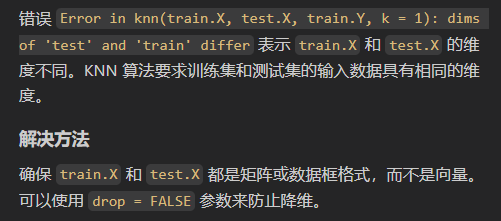

实际上我们查看knn的帮助文档也可以发现参数要求里是matrix或者是df，我们从原始数据中获取最好是保留df数据类型

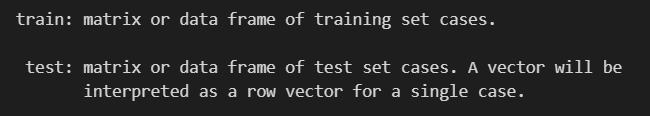

In [ ]:
# g
# 使用KNN，k=1
train_raw.X <- Weekly$Lag2[train]

train.X <- Weekly[train, "Lag2", drop = FALSE] # 这里本质上就是行+列索引index
train.X2 <- Weekly[train, "Lag2", drop = TRUE]

# 我们在这里测试一下
class(train_raw.X) # 'numeric'
class(train.X) # 'data.frame'
class(train.X2) # 'numeric'

is.vector(train_raw.X) # TRUE
is.vector(train.X) # FALSE
is.vector(train.X2) # TRUE
 
is.data.frame(train_raw.X) # FALSE
is.data.frame(train.X) # TRUE
is.data.frame(train.X2) # FALSE

# 所以我们可以看到我们想要使用的数据格式是df，就只能使用train.X格式，而不能使用train_raw.X格式

[1] "numeric"

[1] "data.frame"

[1] "numeric"

[1] TRUE

[1] FALSE

[1] TRUE

[1] FALSE

[1] TRUE

[1] FALSE

In [ ]:
train.X <- Weekly[train, "Lag2", drop = FALSE]
test.X <- Weekly[!train, "Lag2", drop = FALSE]
train.Y <- Weekly$Direction[train]
test.Y <- Weekly$Direction[!train]

knn.pred <- knn(train.X, test.X, train.Y, k = 1)
table(knn.pred, test.Y)
mean(knn.pred == test.Y)

t <- table(knn.pred, test.Y)
sum(diag(t))/sum(t)

# 准确率不是很高，如果是随机猜测的话，使用先验概率是训练集中的涨跌比例，即：
table(Weekly$Direction[train])
table(Weekly$Direction[train]) / length(Weekly$Direction[train])

        test.Y
knn.pred Down Up
    Down   21 30
    Up     22 31

[1] 0.5

[1] 0.5


Down   Up 
 441  544 


     Down        Up 
0.4477157 0.5522843 

In [ ]:
# h
# 使用naive Bayes
nb.fit <- naiveBayes(Direction ~ Lag2, data = Weekly, subset = train)
nb.pred <- predict(nb.fit, Weekly[!train,])
table(nb.pred, Weekly$Direction[!train])
mean(nb.pred == Weekly$Direction[!train])

t <- table(nb.pred, Weekly$Direction[!train])
sum(diag(t))/sum(t) 

# 准确率虽然高，但是还是全都预测为了up

       
nb.pred Down Up
   Down    0  0
   Up     43 61

[1] 0.5865385

[1] 0.5865385



i ： 如果仅仅是从结果上看的话，那么逻辑回归以及LDA的测试集上的预测效果最好

The following objects are masked from Weekly (pos = 3):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year


The following objects are masked from Weekly (pos = 7):

    Direction, Lag1, Lag2, Lag3, Lag4, Lag5, Today, Volume, Year




[1] 0.5673077

[1] 0.5865385

[1] 0.5865385

[1] 0.5865385

...

[1] 0.5192308

[1] 0.5096154

[1] 26

      
fit    Down Up
  Down   23 18
  Up     20 43

[1] 0.6346154

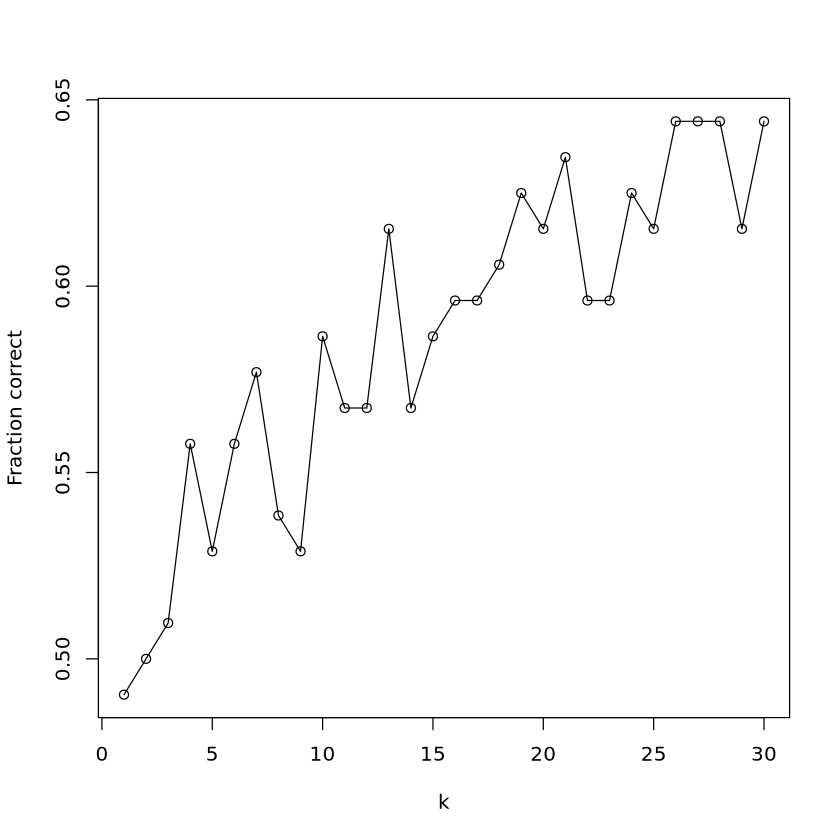

In [8]:
# j

library(MASS)
library(class)
library(ISLR2)
library(e1071)
attach(Weekly)
train <- (Year < 2009)

# 还是逻辑回归，但是使用变量Lag1
fit <- glm(Direction ~ Lag1, data = Weekly[train, ], family = binomial)
pred <- predict(fit, Weekly[!train, ], type = "response") > 0.5
mean(ifelse(pred, "Up", "Down") == Weekly[!train, ]$Direction)

# 使用变量Lag3
fit <- glm(Direction ~ Lag3, data = Weekly[train, ], family = binomial)
pred <- predict(fit, Weekly[!train, ], type = "response") > 0.5
mean(ifelse(pred, "Up", "Down") == Weekly[!train, ]$Direction)

# 使用变量Lag4
fit <- glm(Direction ~ Lag4, data = Weekly[train, ], family = binomial)
pred <- predict(fit, Weekly[!train, ], type = "response") > 0.5
mean(ifelse(pred, "Up", "Down") == Weekly[!train, ]$Direction)

# 使用变量组合lag1+lag2+lag3+lag4
fit <- glm(Direction ~ Lag1 + Lag2 + Lag3 + Lag4, data = Weekly[train, ], family = binomial)
pred <- predict(fit, Weekly[!train, ], type = "response") > 0.5
mean(ifelse(pred, "Up", "Down") == Weekly[!train, ]$Direction)

# 使用变量组合lag1*lag2*lag3*lag4
fit <- glm(Direction ~ Lag1 * Lag2 * Lag3 * Lag4, data = Weekly[train, ], family = binomial)
pred <- predict(fit, Weekly[!train, ], type = "response") > 0.5
mean(ifelse(pred, "Up", "Down") == Weekly[!train, ]$Direction)

# 使用lda模型，同时使用lag1+lag2+lag3+lag4
fit <- lda(Direction ~ Lag1 + Lag2 + Lag3 + Lag4, data = Weekly[train, ])
pred <- predict(fit, Weekly[!train, ], type = "response")$class
mean(pred == Weekly[!train, ]$Direction)

# 使用qda模型，同时使用lag1+lag2+lag3+lag4
fit <- qda(Direction ~ Lag1 + Lag2 + Lag3 + Lag4, data = Weekly[train, ])
pred <- predict(fit, Weekly[!train, ], type = "response")$class
mean(pred == Weekly[!train, ]$Direction)

# 使用naive Bayes模型，同时使用lag1+lag2+lag3+lag4
fit <- naiveBayes(Direction ~ Lag1 + Lag2 + Lag3 + Lag4, data = Weekly[train, ])
pred <- predict(fit, Weekly[!train, ], type = "class")
mean(pred == Weekly[!train, ]$Direction)

# 使用knn模型，同时使用lag1+lag2+lag3，设置随机种子，且k=1-30
set.seed(1)
res <- sapply(1:30, function(k) {
  fit <- knn(
    Weekly[train, 2:4, drop = FALSE],
    Weekly[!train, 2:4, drop = FALSE],
    Weekly$Direction[train],
    k = k
  )
  mean(fit == Weekly[!train, ]$Direction)
})
plot(1:30, res, type = "o", xlab = "k", ylab = "Fraction correct")
(k <- which.max(res))

# 使用最优的k值
fit <- knn(
  Weekly[train, 2:4, drop = FALSE],
  Weekly[!train, 2:4, drop = FALSE],
  Weekly$Direction[train],
  k = k
)
table(fit, Weekly[!train, ]$Direction)
mean(fit == Weekly[!train, ]$Direction)

如果我们将k调整为k = 26，使用前3个滞后变量的KNN比使用‘ Lag2 ’的逻辑回归性能略好。

In [3]:
Weekly[,2:4]

,Lag1,Lag2,Lag3
,<dbl>,<dbl>,<dbl>
1,0.816,1.572,-3.936
2,-0.270,0.816,1.572
3,-2.576,-0.270,0.816
4,3.514,-2.576,-0.270
5,0.712,3.514,-2.576
6,1.178,0.712,3.514
7,-1.372,1.178,0.712
8,0.807,-1.372,1.178
9,0.041,0.807,-1.372


15，

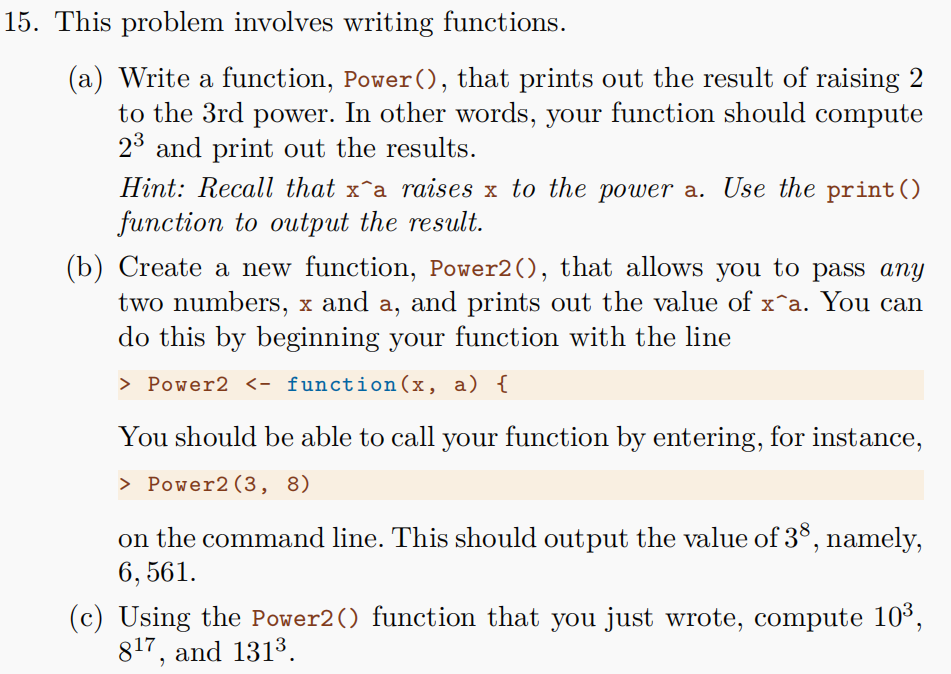

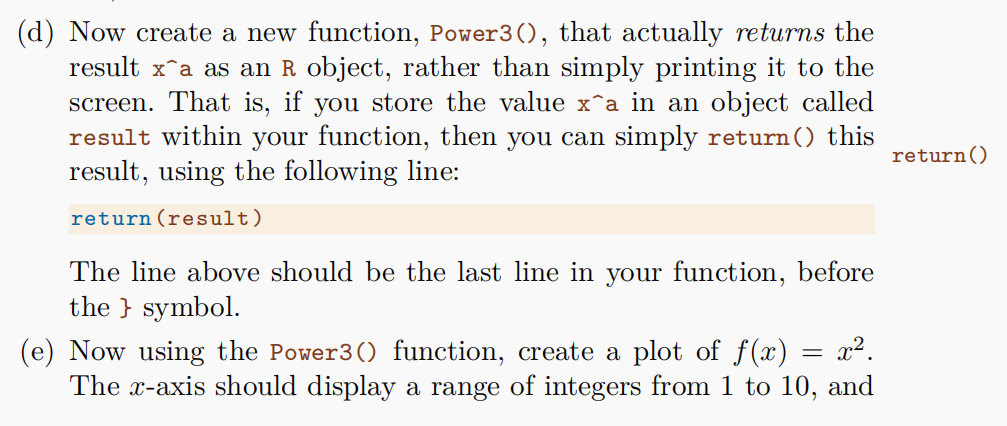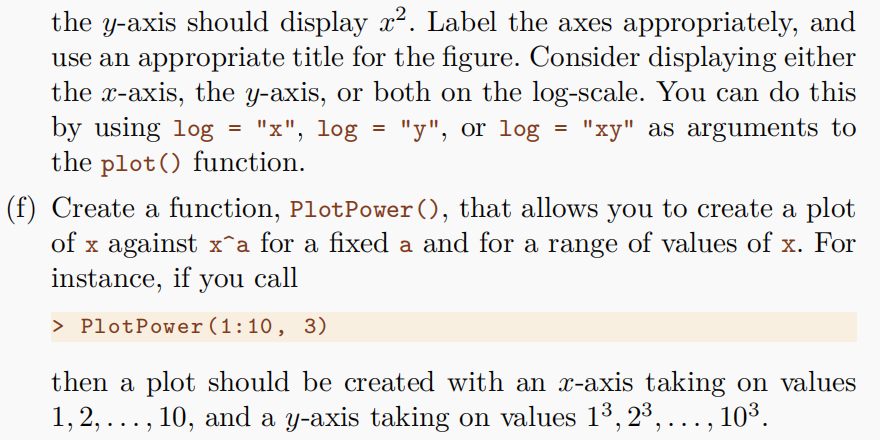

In [15]:
# a
Power <- function(x,a){
    print(x^a)
}
Power(2,3)

# 或者再直接一点
Power <- function(){
    print(2^3)
}
Power()

[1] 8
[1] 8


In [16]:
# b
Power2 <- function(x,a){
    print(x^a)
}
Power2(2,3)
Power2(3, 8)

[1] 8
[1] 6561


In [18]:
# c
Power2(10,3)
Power2(8,17)
power2(131,3)

[1] 1000
[1] 2.2518e+15
[1] 2248091


In [19]:
# d
Power3 <- function(x,a){
    result <- x^a;
    return(result)
}

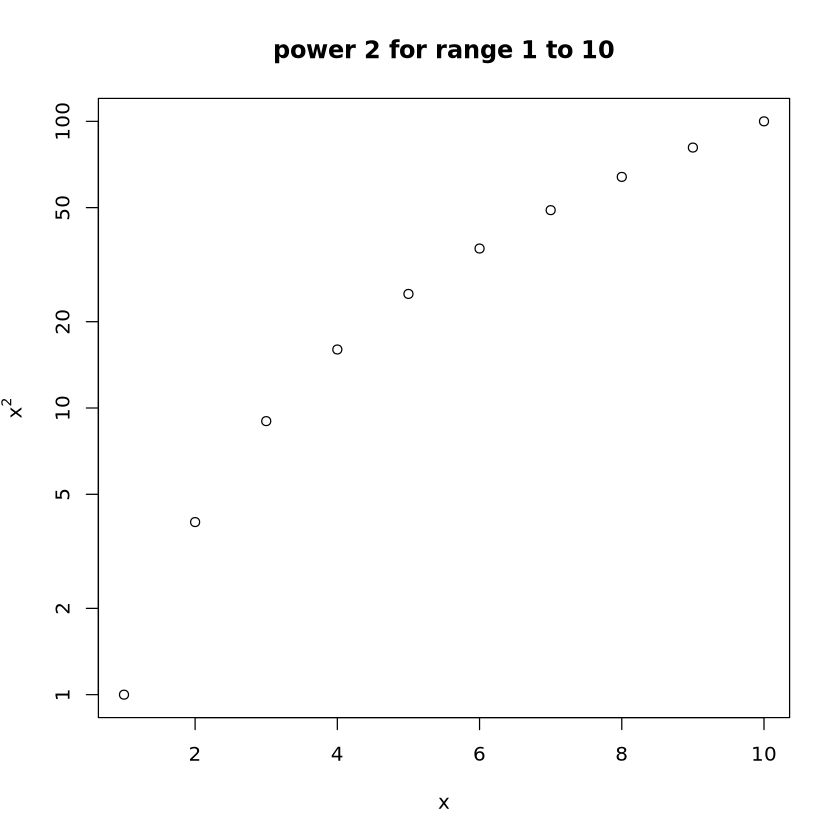

In [22]:
# e 

plot(1:10, Power3(1:10, 2),
  xlab = "x",
  ylab = expression(paste("x"^"2")),
  log = "y",
  main="power 2 for range 1 to 10"
)

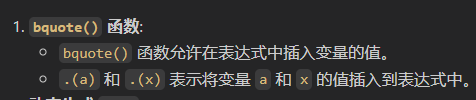

 [1]    1    8   27   64  125  216  343  512  729 1000


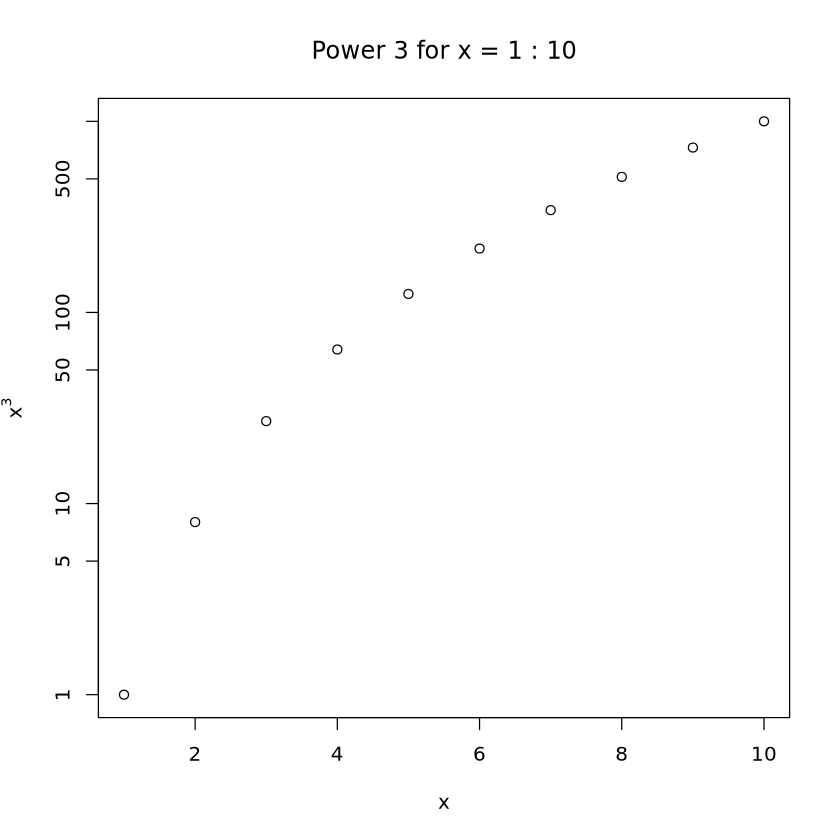

In [32]:
# f
PlotPower <- function(x, a) {
  plot(x, Power2(x, a),
       xlab = "x",
       ylab = bquote(x^.(a)),
       log = "y",
       main = bquote("Power " * .(a) * " for x = " * .(x))
  )
}  # 这里的x字符串被解释为第1个元素

PlotPower <- function(x, a) {
  plot(x, Power2(x, a),
       xlab = "x",
       ylab = bquote(x^.(a)),
       log = "y",
       main = bquote("Power " * .(a) * " for x = " * .(paste(min(x), ":", max(x))))
  )
}  # 这里的x字符串被解释为范围

PlotPower(1:10, 3)

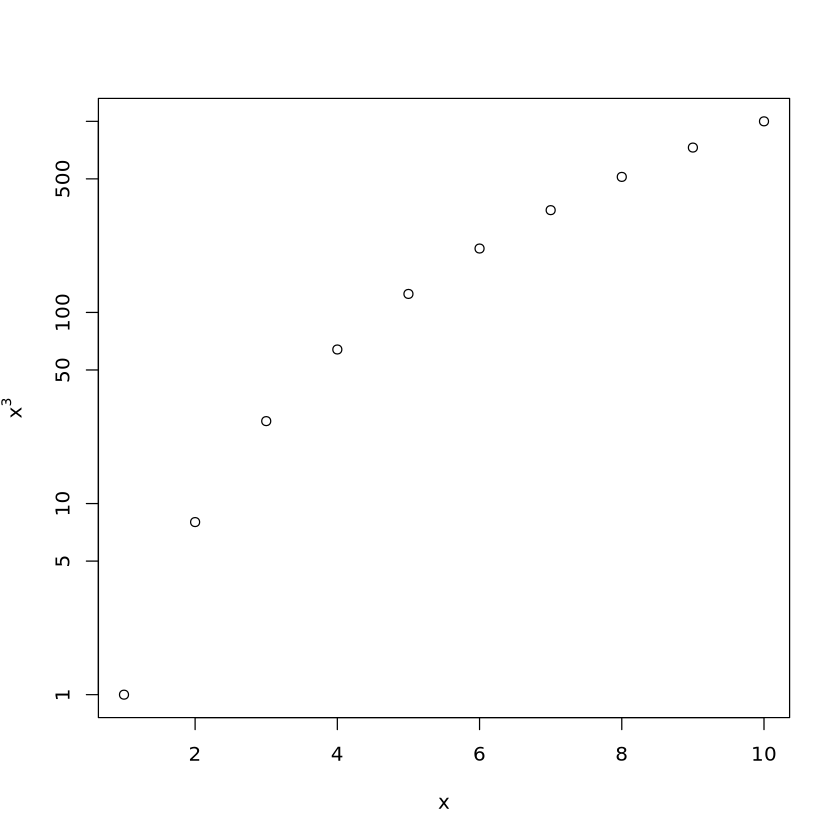

In [30]:
PlotPower <- function(x, a, log = "y") {
  plot(x, Power3(x, a),
    xlab = "x",
    ylab = substitute("x"^a, list(a = a)),
    log = log
  )
}
PlotPower(1:10, 3)